In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
trainPath = r'dataset\train.csv'
testPath = r'dataset\test.csv'

In [3]:
trainData= pd.read_csv(trainPath)
testData = pd.read_csv(testPath)

In [4]:
trainData

,Component1_fraction,Component2_fraction,Component3_fraction,Component4_fraction,Component5_fraction,Component1_Property1,Component2_Property1,Component3_Property1,Component4_Property1,Component5_Property1,...,BlendProperty1,BlendProperty2,BlendProperty3,BlendProperty4,BlendProperty5,BlendProperty6,BlendProperty7,BlendProperty8,BlendProperty9,BlendProperty10
0,0.21,0.00,0.42,0.25,0.12,-0.021782,1.981251,0.020036,0.140315,1.032029,...,0.489143,0.607589,0.321670,-1.236055,1.601132,1.384662,0.305850,0.193460,0.580374,-0.762738
1,0.02,0.33,0.19,0.46,0.00,-0.224339,1.148036,-1.107840,0.149533,-0.354000,...,-1.257481,-1.475283,-0.437385,-1.402911,0.147941,-1.143244,-0.439171,-1.379041,-1.280989,-0.503625
2,0.08,0.08,0.18,0.50,0.16,0.457763,0.242591,-0.922492,0.908213,0.972003,...,1.784349,0.450467,0.622687,1.375614,-0.428790,1.161616,0.601289,0.872950,0.660000,2.024576
3,0.25,0.42,0.00,0.07,0.26,-0.577734,-0.930826,0.815284,0.447514,0.455717,...,-0.066422,0.483730,-1.865442,-0.046295,-0.163820,-0.209693,-1.840566,0.300293,-0.351336,-1.551914
4,0.26,0.16,0.08,0.50,0.00,0.120415,0.666268,-0.626934,2.725357,0.392259,...,-0.118913,-1.172398,0.301785,-1.787407,-0.493361,-0.528049,0.286344,-0.265192,0.430513,0.735073
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,0.50,0.12,0.00,0.26,0.12,0.279523,-0.054170,-0.391227,0.400222,1.032029,...,-0.028366,-0.327297,-0.316933,-1.294092,-0.530259,-0.421526,-0.320869,0.709627,-0.737244,-0.744289
1996,0.19,0.31,0.00,0.37,0.13,-0.887185,0.610050,0.178606,1.083154,-2.822749,...,-0.449245,0.156778,-0.367445,-0.938615,-0.577451,-0.209996,-0.370505,-0.195531,-0.032834,0.269718
1997,0.38,0.06,0.14,0.31,0.11,0.568978,-0.196759,-0.646318,-0.980070,1.032029,...,0.029135,0.164890,-0.092942,-1.134490,-0.437479,-0.695636,-0.101073,0.063650,0.624368,-0.477053
1998,0.50,0.16,0.00,0.18,0.16,-0.067453,0.321977,-0.137535,0.238507,0.017455,...,-0.232960,-0.464947,0.112536,-0.793522,-0.811272,-1.194914,0.100644,0.760116,-0.751394,-0.857598


In [5]:
trainColumns = set(trainData.columns)
testColumns = set(testData.columns)

In [6]:
difference = trainColumns.difference(testColumns)
difference

{'BlendProperty1',
 'BlendProperty10',
 'BlendProperty2',
 'BlendProperty3',
 'BlendProperty4',
 'BlendProperty5',
 'BlendProperty6',
 'BlendProperty7',
 'BlendProperty8',
 'BlendProperty9'}

All target columns, No missing features in test

## Target Variable Analysis

In [26]:
targeColumns = ['BlendProperty1',
 'BlendProperty2',
 'BlendProperty3',
 'BlendProperty4',
 'BlendProperty5',
 'BlendProperty6',
 'BlendProperty7',
 'BlendProperty8',
 'BlendProperty9',
 'BlendProperty10']

In [48]:
Y = trainData[targeColumns]
Y

,BlendProperty1,BlendProperty2,BlendProperty3,BlendProperty4,BlendProperty5,BlendProperty6,BlendProperty7,BlendProperty8,BlendProperty9,BlendProperty10
0,0.489143,0.607589,0.321670,-1.236055,1.601132,1.384662,0.305850,0.193460,0.580374,-0.762738
1,-1.257481,-1.475283,-0.437385,-1.402911,0.147941,-1.143244,-0.439171,-1.379041,-1.280989,-0.503625
2,1.784349,0.450467,0.622687,1.375614,-0.428790,1.161616,0.601289,0.872950,0.660000,2.024576
3,-0.066422,0.483730,-1.865442,-0.046295,-0.163820,-0.209693,-1.840566,0.300293,-0.351336,-1.551914
4,-0.118913,-1.172398,0.301785,-1.787407,-0.493361,-0.528049,0.286344,-0.265192,0.430513,0.735073
...,...,...,...,...,...,...,...,...,...,...
1995,-0.028366,-0.327297,-0.316933,-1.294092,-0.530259,-0.421526,-0.320869,0.709627,-0.737244,-0.744289
1996,-0.449245,0.156778,-0.367445,-0.938615,-0.577451,-0.209996,-0.370505,-0.195531,-0.032834,0.269718
1997,0.029135,0.164890,-0.092942,-1.134490,-0.437479,-0.695636,-0.101073,0.063650,0.624368,-0.477053
1998,-0.232960,-0.464947,0.112536,-0.793522,-0.811272,-1.194914,0.100644,0.760116,-0.751394,-0.857598


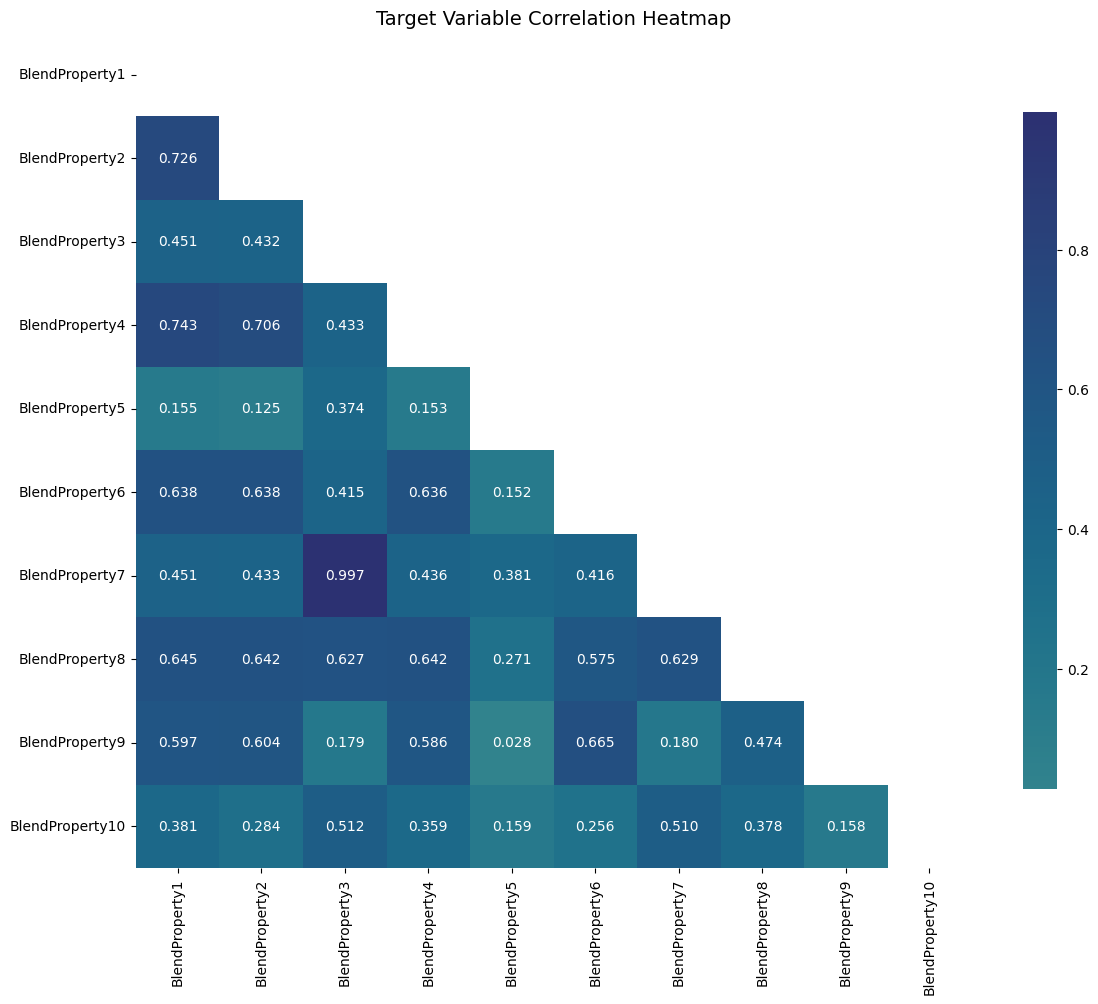

In [9]:
label_correlation_matrix = Y.corr()

plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(label_correlation_matrix, dtype=bool))

sns.heatmap(label_correlation_matrix, 
            mask=mask,
            annot=True, 
            cmap='crest', 
            center=0,
            square=True, 
            fmt='.3f',
            cbar_kws={"shrink": .8})

plt.title('Target Variable Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

In [10]:
def scattercorel(dataframe, property1, property2, figsize: tuple=None):
    n = len(property1)
    rows = 2
    cols = (n + 1) // 2 

    fig, ax = plt.subplots(rows, cols, figsize=figsize or (10 * cols, 10), constrained_layout=True)
    ax = ax.flatten()  

    for i, (p1, p2) in enumerate(zip(property1, property2)):
        ax[i].scatter(dataframe[p1], dataframe[p2], alpha=0.6, color="#E80AE4")
        ax[i].set_xlabel(p1)
        ax[i].set_ylabel(p2)
        ax[i].set_title(f'{p1} vs {p2}')
        ax[i].grid(True)

    for j in range(i + 1, len(ax)):
        ax[j].axis('off')

    plt.show()

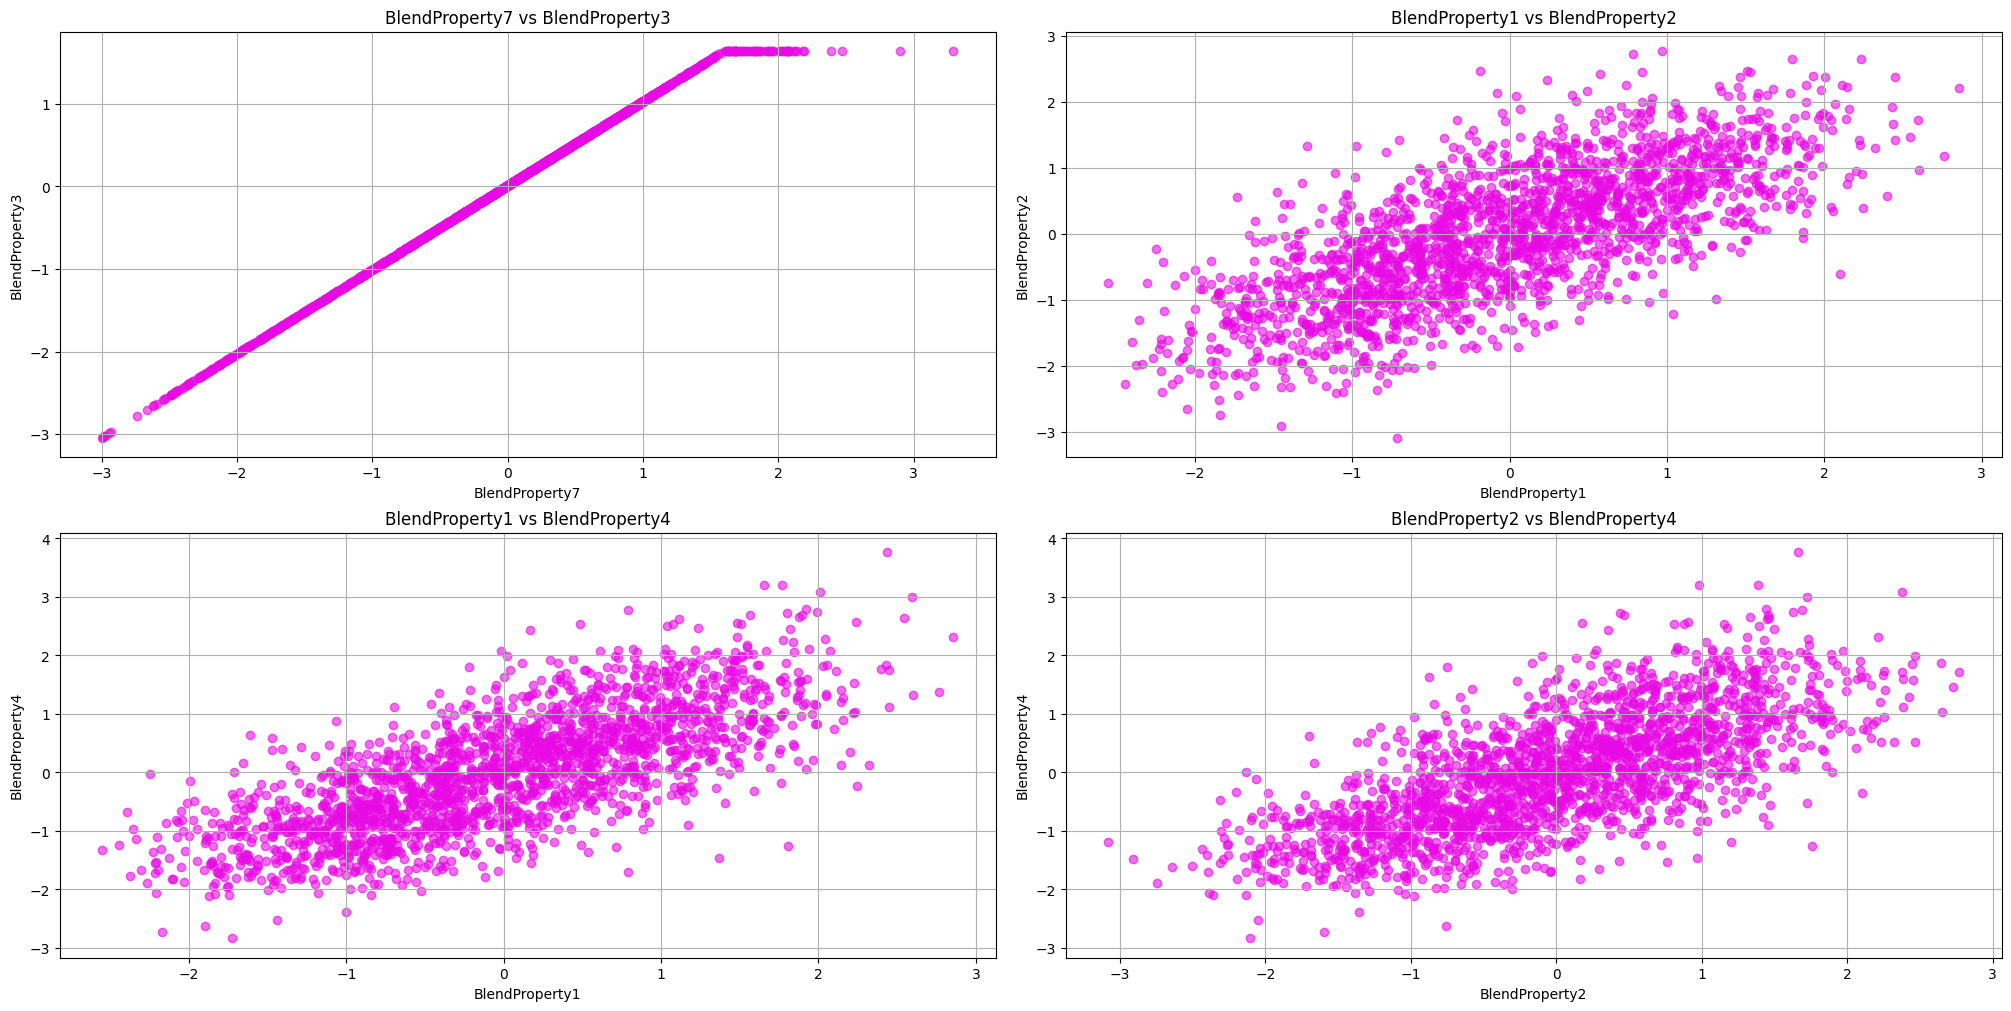

In [11]:
scattercorel(Y, ['BlendProperty7', 'BlendProperty1', 'BlendProperty1', 'BlendProperty2'], ['BlendProperty3', 'BlendProperty2', 'BlendProperty4', 'BlendProperty4'])

In [12]:
def outskew(df, column: str):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]

    fig, ax = plt.subplots(1, 2, figsize=(16, 8))

    target = df[column].values
    skew = df[column].skew()

    ax[0].boxplot(target, vert=False)
    ax[0].set_title(f'Distribution Box Plot for {column}')

    
    sns.histplot(target, bins=100, kde=True, ax=ax[1], color='skyblue', edgecolor='navy', alpha=0.7)
    ax[1].axvline(np.mean(target), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(target):.4f}')
    ax[1].axvline(np.median(target), color='green', linestyle='--', linewidth=2, label=f'Median: {np.median(target):.4f}')
    ax[1].set_title(f'Distribution Histogram for {column}, Skew: {skew:.3f}', fontsize=14, pad=10)
    ax[1].set_xlabel('Target Value', fontsize=12)
    ax[1].set_ylabel('Frequency', fontsize=12)
    ax[1].legend(fontsize=10, framealpha=0.9)
    ax[1].grid(True, alpha=0.3)

    stats_text = f"""
    Min: {np.min(target):.2f}
    Q1: {Q1:.2f}
    Median: {np.median(target):.2f}
    Q3: {Q3:.2f}
    Max: {np.max(target):.2f}
    IQR: {IQR:.2f}
    Outliers: {len(outliers)}
    """
    ax[1].text(1.05, 0.5, stats_text, transform=ax[1].transAxes, 
               bbox=dict(facecolor='white', alpha=0.8), fontsize=10)

    plt.tight_layout()
    plt.show()

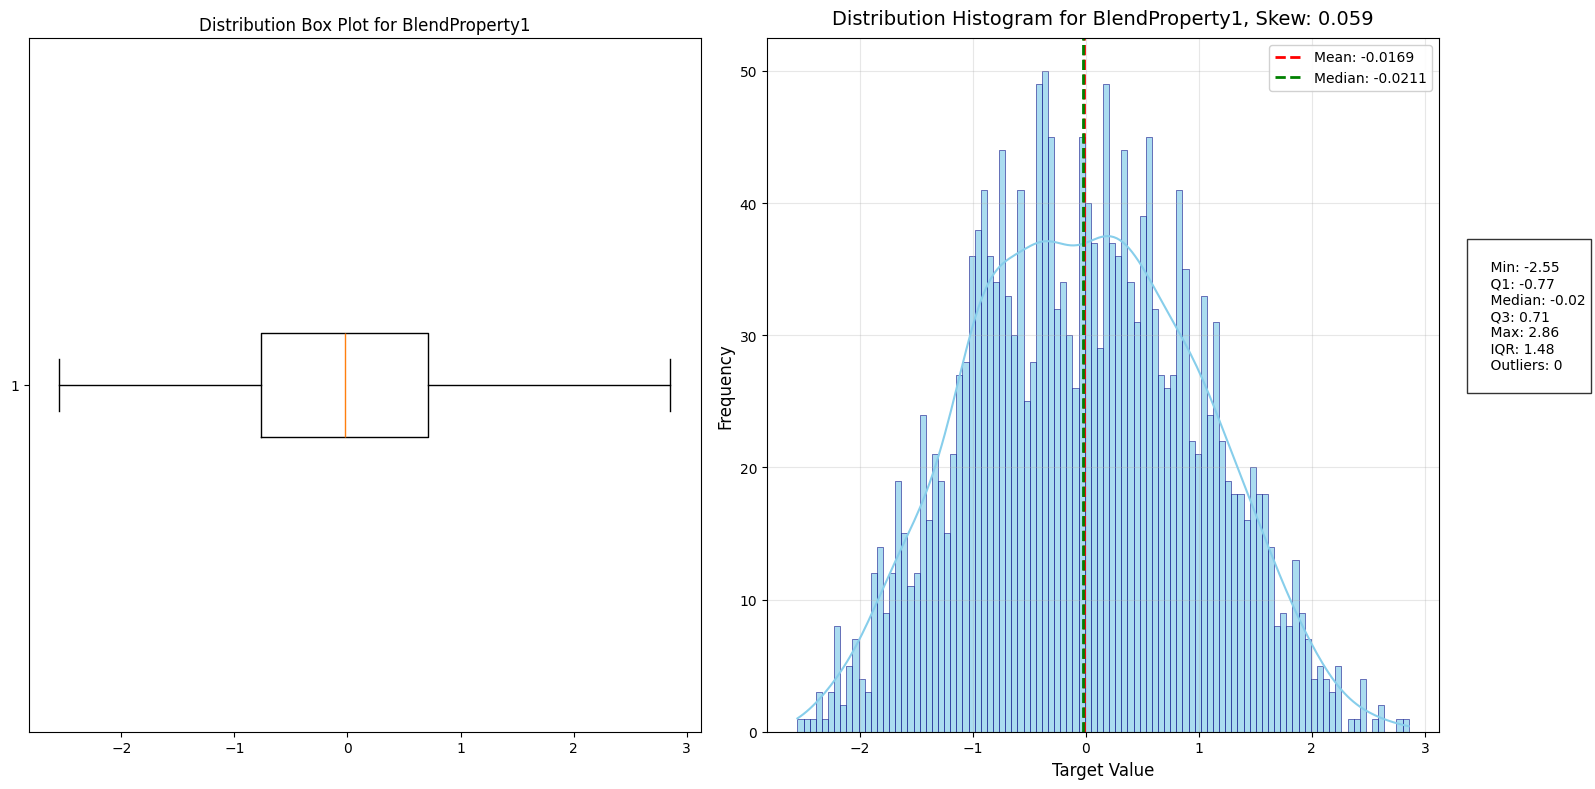

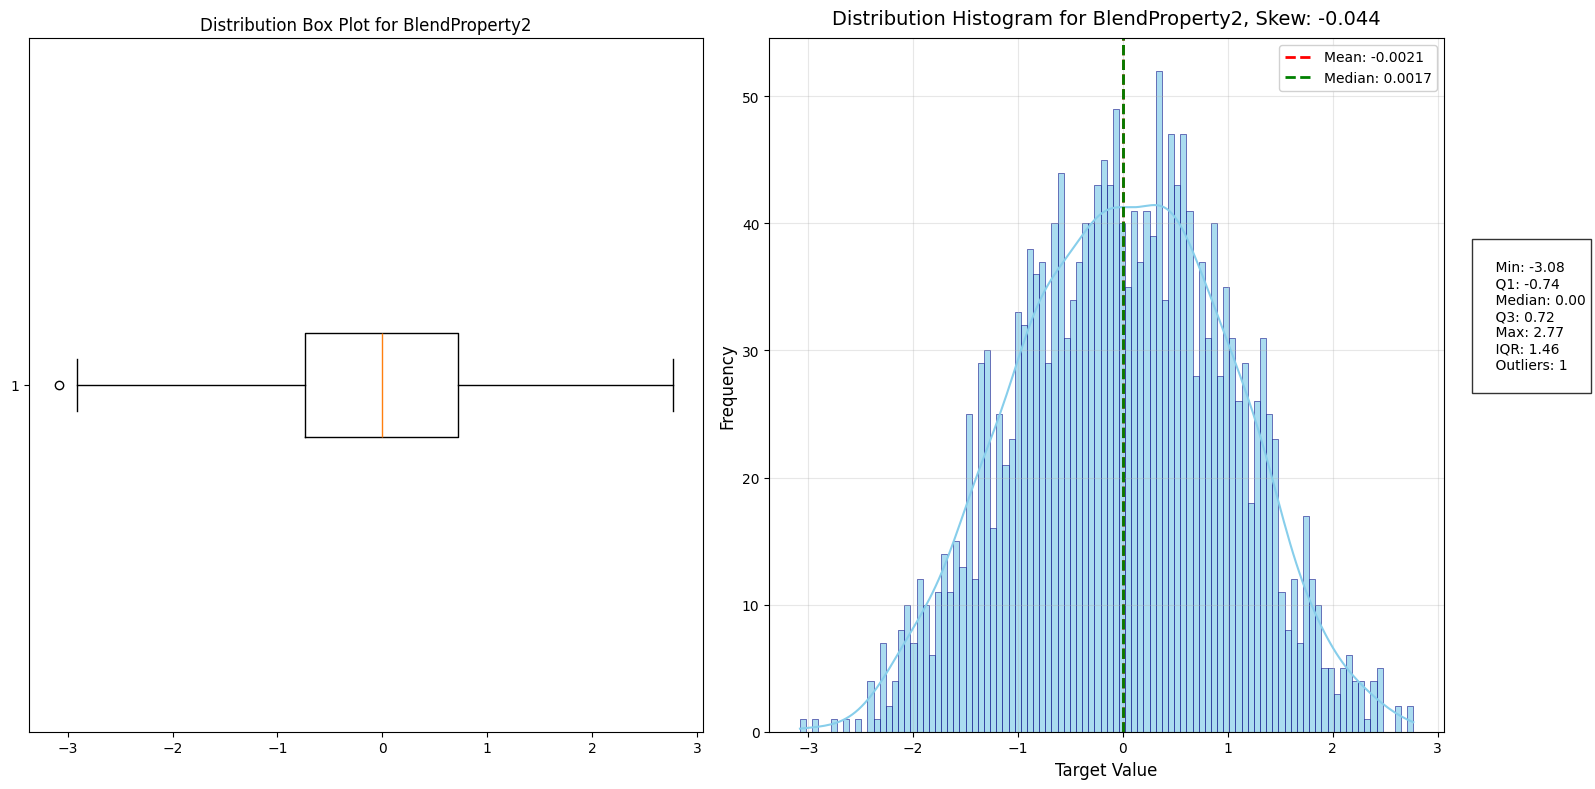

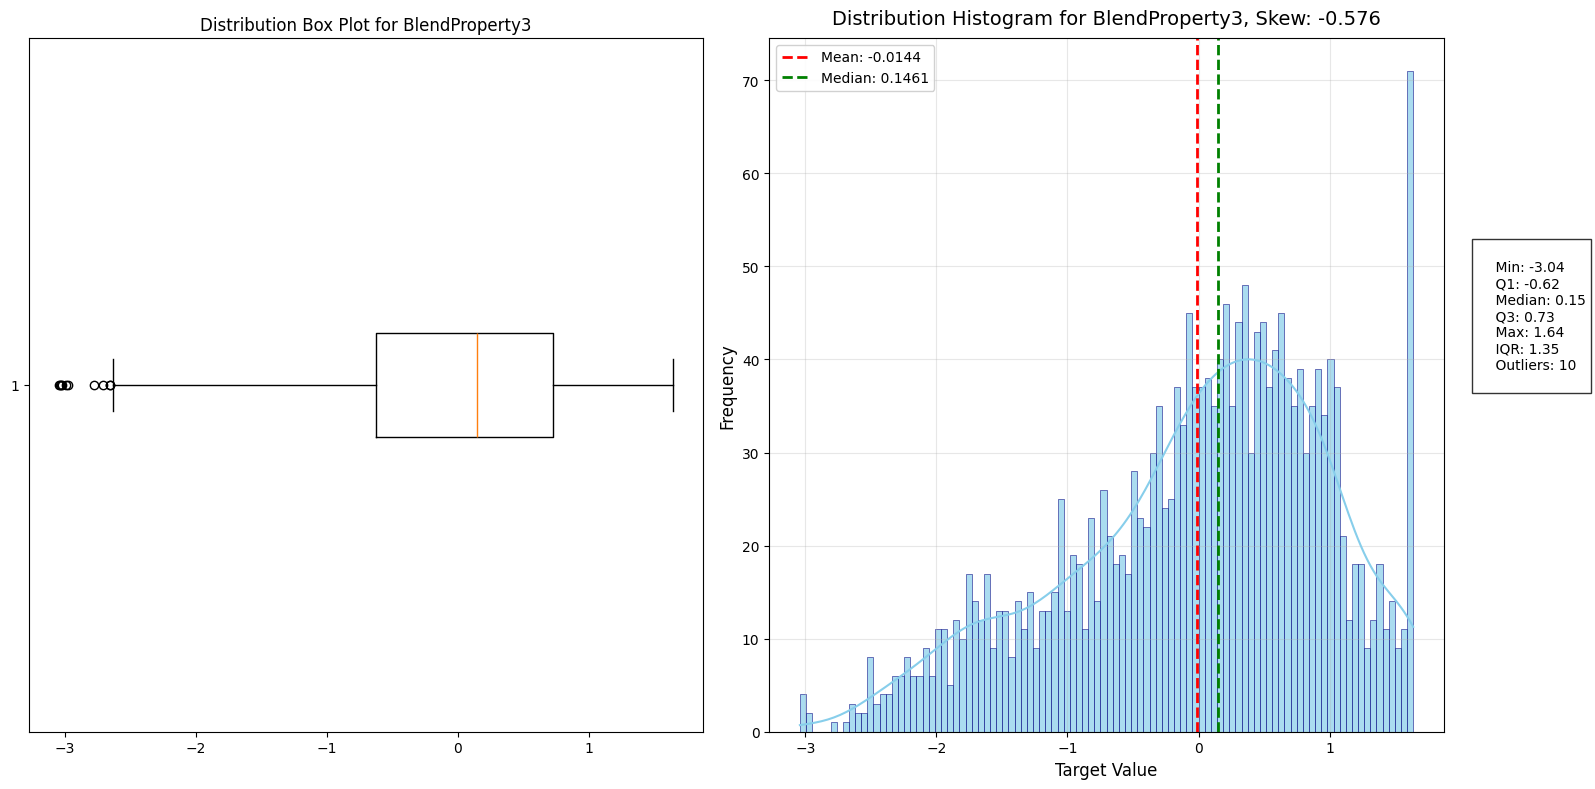

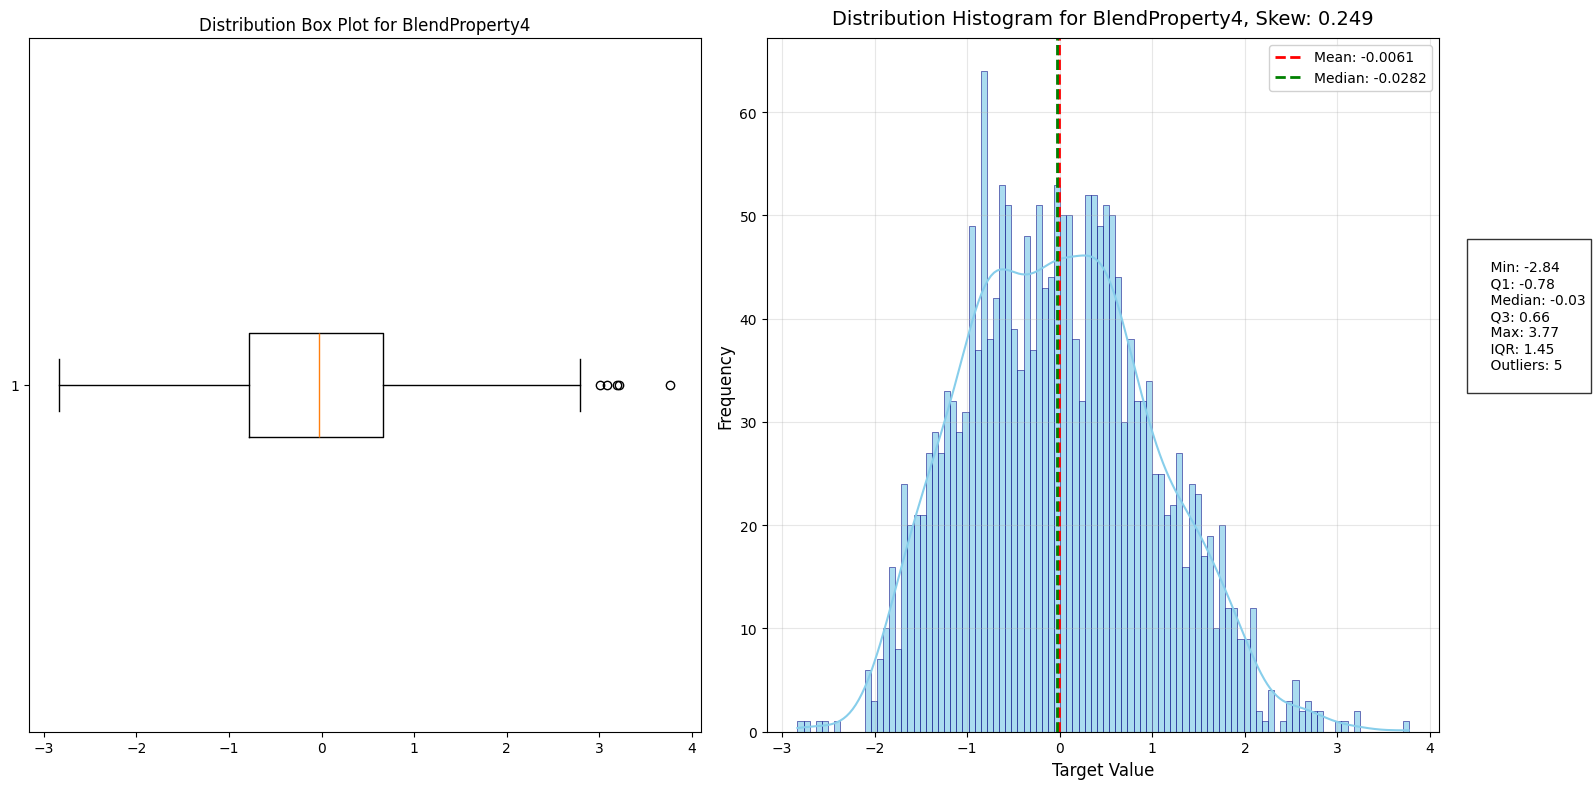

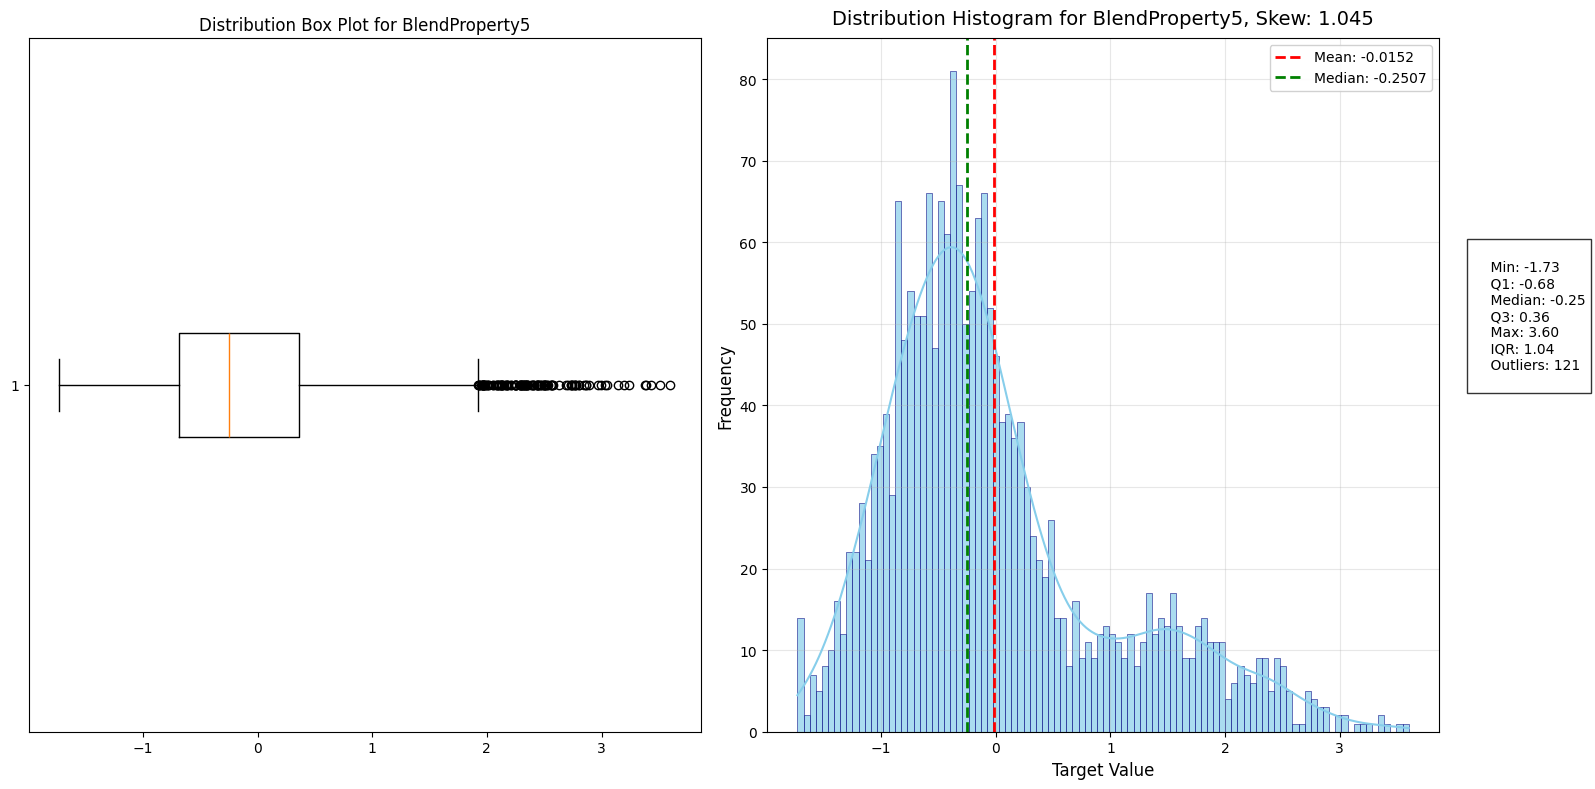

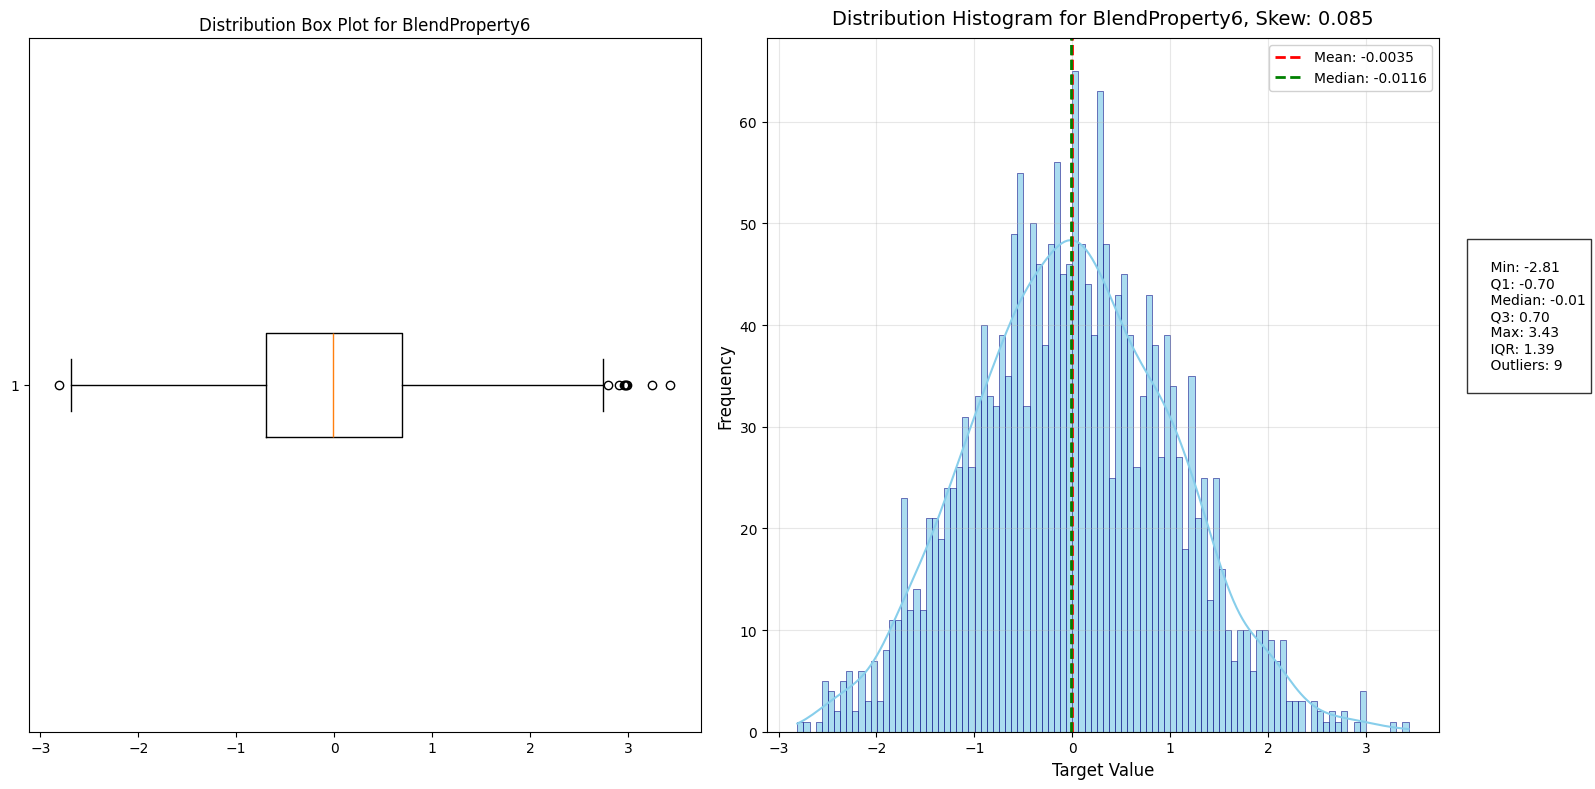

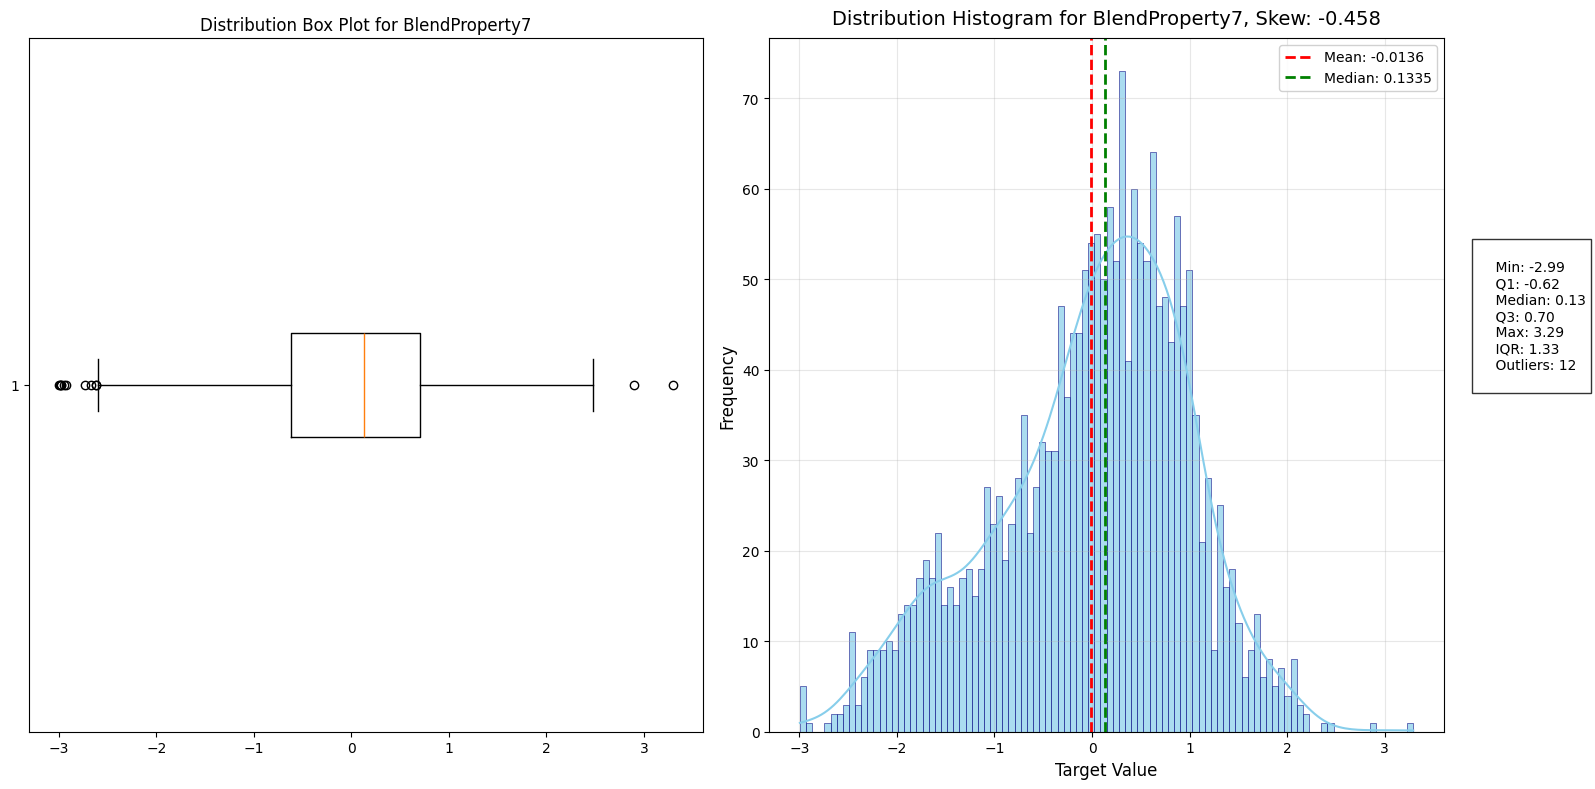

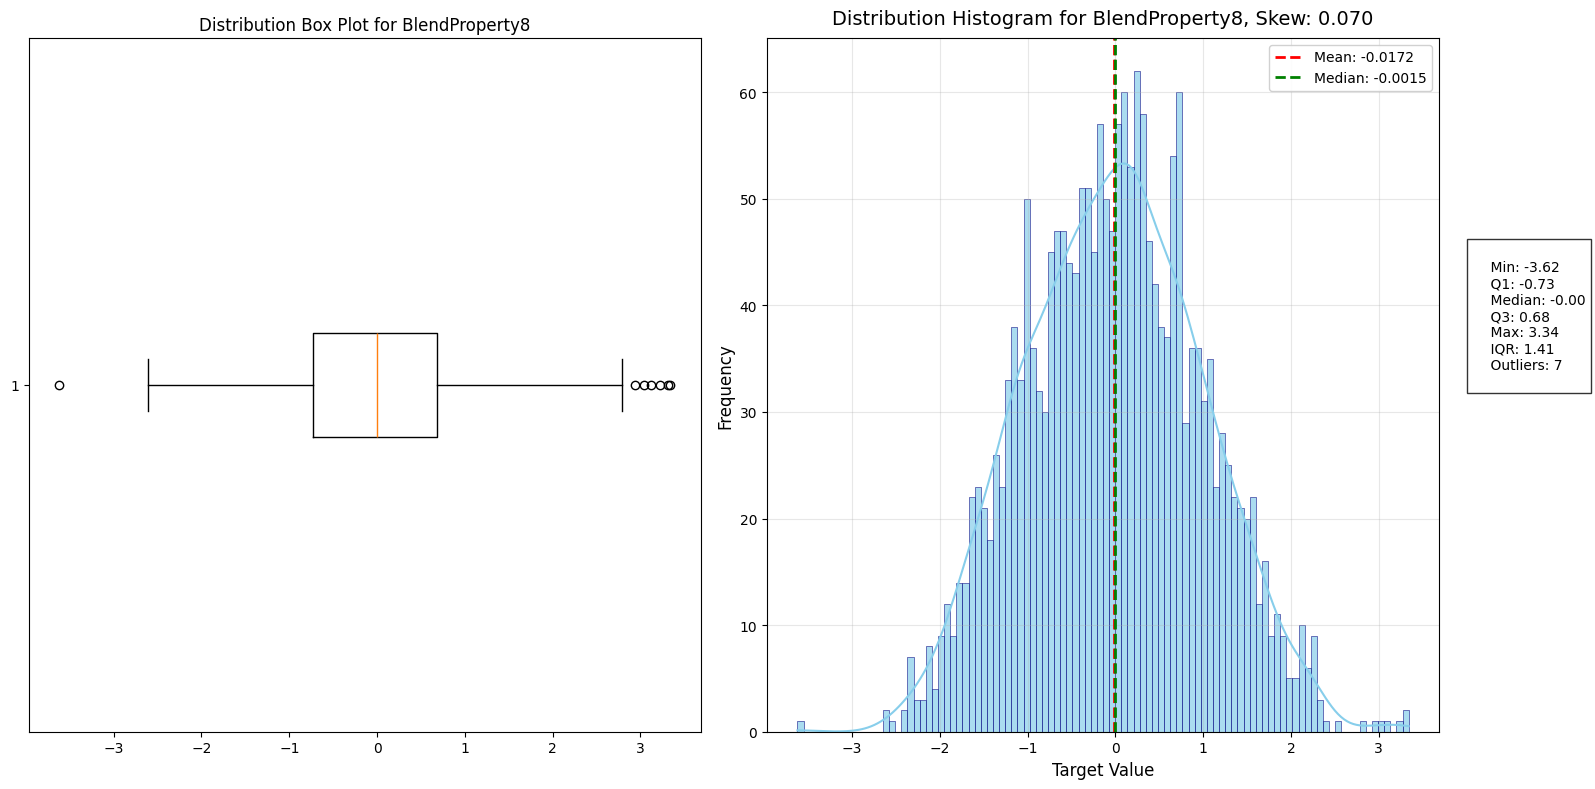

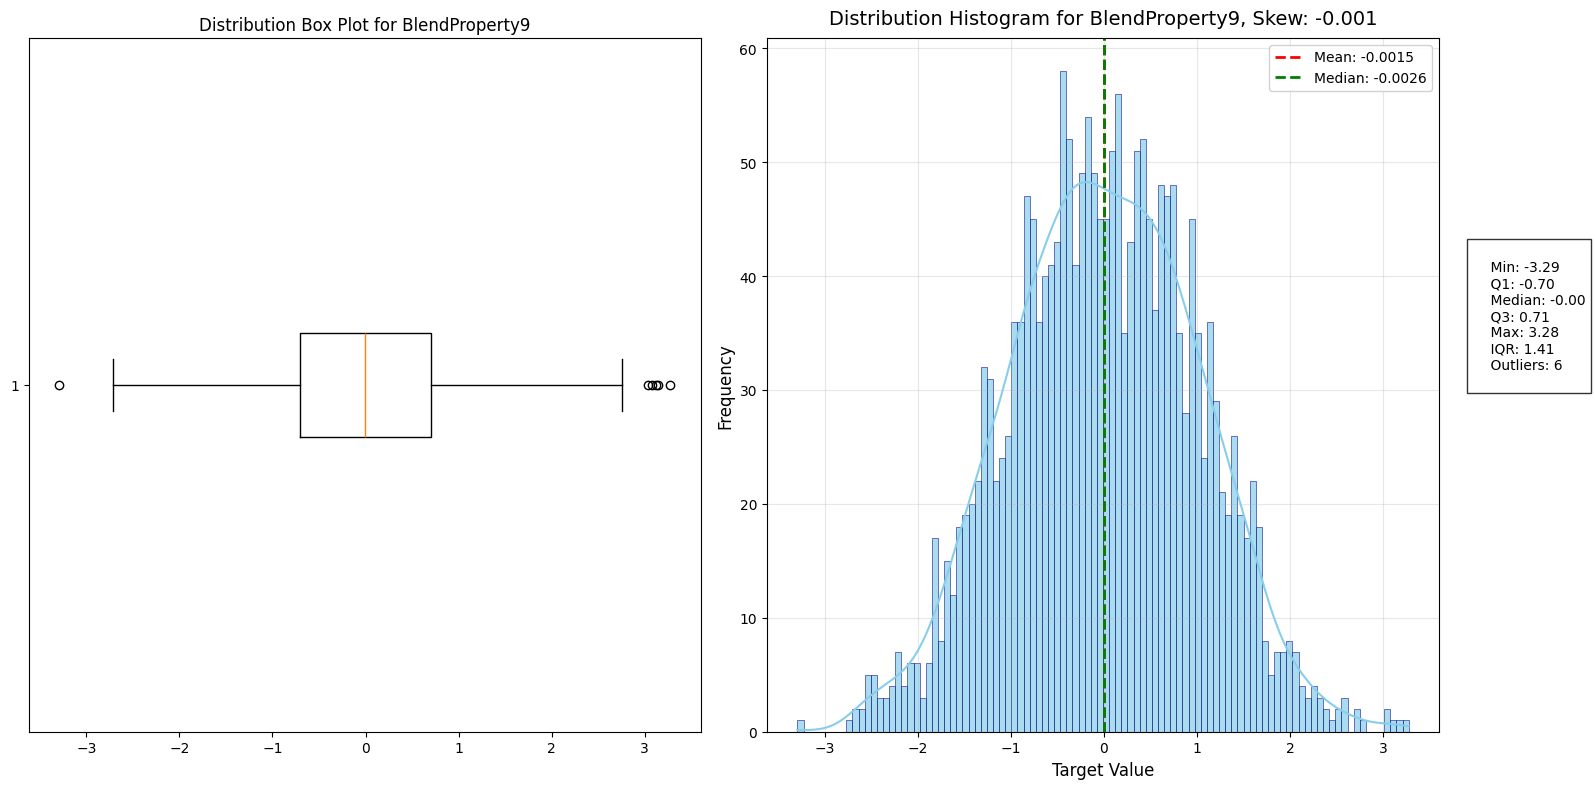

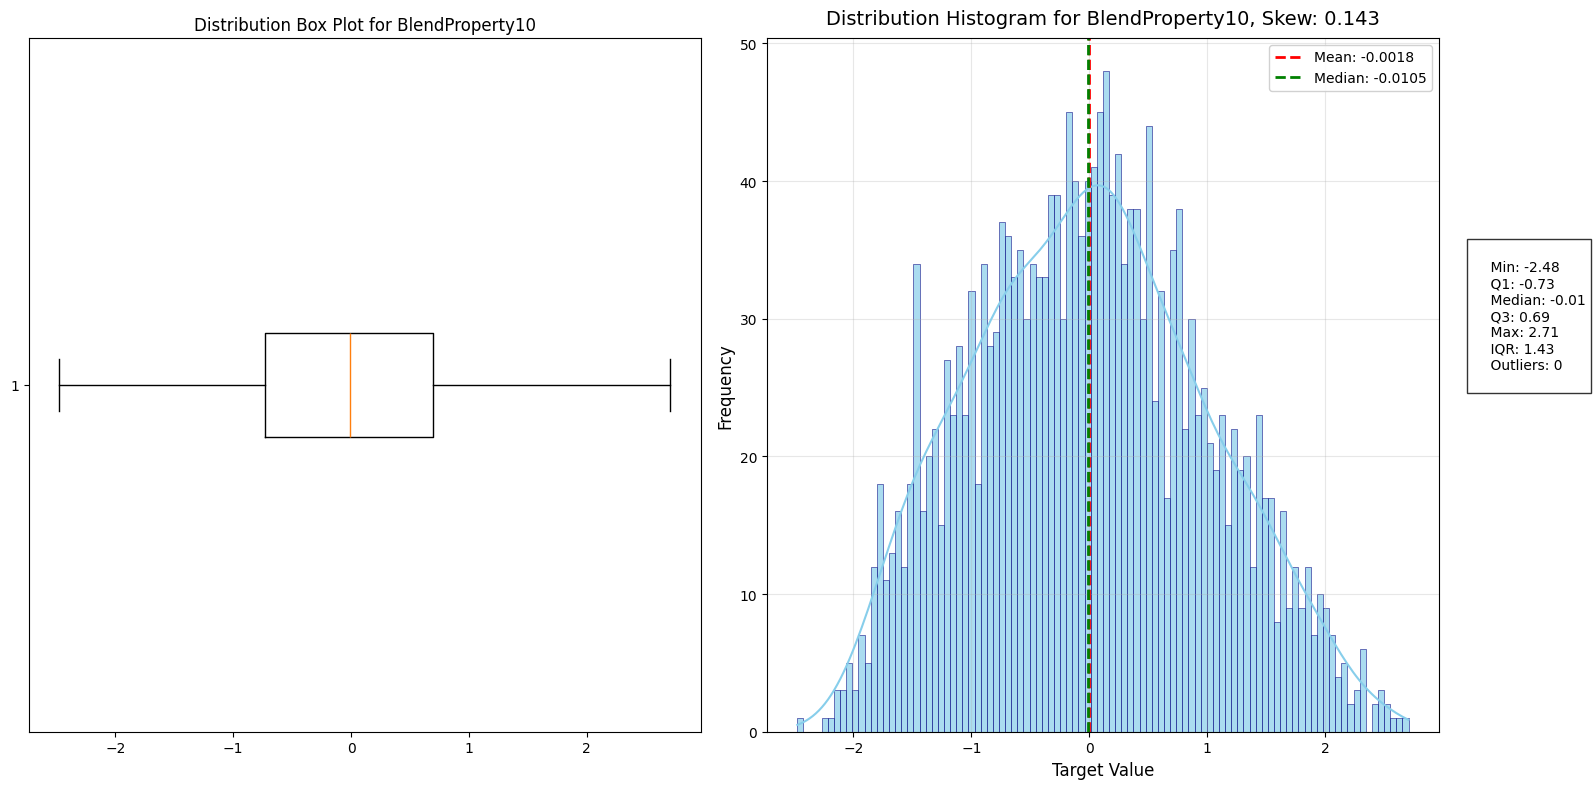

In [13]:
for target in Y.columns:
    outskew(Y, target)

In [14]:
Y.isna().sum()

BlendProperty1     0
BlendProperty2     0
BlendProperty3     0
BlendProperty4     0
BlendProperty5     0
BlendProperty6     0
BlendProperty7     0
BlendProperty8     0
BlendProperty9     0
BlendProperty10    0
dtype: int64

1. No null values in any Target Variable


2. #### Skewness & Outliers
- 1, 2, 4, 6, 8, 9, 10 Blends have negligible skew and outliers.
- Blend 3 and 7 have a slight left skew with minimal outliers.
- Blend 5 has large right skew and considerable outliers.

3. #### Correlation
- Blend 3 and 7 are highly correlated, except that all have medium to low correlation amongst each other

## Feature Analysis

In [15]:
X = trainData.drop(columns=targeColumns)
X

,Component1_fraction,Component2_fraction,Component3_fraction,Component4_fraction,Component5_fraction,Component1_Property1,Component2_Property1,Component3_Property1,Component4_Property1,Component5_Property1,...,Component1_Property9,Component2_Property9,Component3_Property9,Component4_Property9,Component5_Property9,Component1_Property10,Component2_Property10,Component3_Property10,Component4_Property10,Component5_Property10
0,0.21,0.00,0.42,0.25,0.12,-0.021782,1.981251,0.020036,0.140315,1.032029,...,0.480368,1.044967,-0.450956,0.674572,-0.636394,-1.244963,-1.355050,-0.314423,0.993593,-2.728928
1,0.02,0.33,0.19,0.46,0.00,-0.224339,1.148036,-1.107840,0.149533,-0.354000,...,-1.958826,-0.019603,-0.807923,0.148715,1.439313,-1.160435,-0.014276,-0.135968,-1.221155,0.896222
2,0.08,0.08,0.18,0.50,0.16,0.457763,0.242591,-0.922492,0.908213,0.972003,...,-0.798978,-0.444027,0.148405,-0.793607,0.123834,0.006829,0.668734,0.015449,-0.098661,-0.424314
3,0.25,0.42,0.00,0.07,0.26,-0.577734,-0.930826,0.815284,0.447514,0.455717,...,-0.534135,1.155513,-0.760428,0.450159,-0.973779,0.052972,-1.024785,0.118951,2.400556,-0.576430
4,0.26,0.16,0.08,0.50,0.00,0.120415,0.666268,-0.626934,2.725357,0.392259,...,-0.389350,1.799238,-0.912374,1.767557,-0.467038,2.104922,0.858593,-0.469110,0.715789,-2.038341
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,0.50,0.12,0.00,0.26,0.12,0.279523,-0.054170,-0.391227,0.400222,1.032029,...,1.138839,1.666804,-1.413339,0.405253,0.766653,-0.322096,1.399468,1.096369,-0.346225,0.641193
1996,0.19,0.31,0.00,0.37,0.13,-0.887185,0.610050,0.178606,1.083154,-2.822749,...,-0.782418,0.784366,1.113626,1.328112,-2.537512,0.461525,0.647984,-0.618766,-0.047918,0.397253
1997,0.38,0.06,0.14,0.31,0.11,0.568978,-0.196759,-0.646318,-0.980070,1.032029,...,-0.813747,-0.197880,-0.549162,0.810814,1.567580,-0.694918,-1.710215,-0.233936,-0.133002,-0.284672
1998,0.50,0.16,0.00,0.18,0.16,-0.067453,0.321977,-0.137535,0.238507,0.017455,...,1.262477,-0.925444,-0.823345,0.427648,-0.161447,0.628131,-0.038484,0.343058,0.448748,0.193507


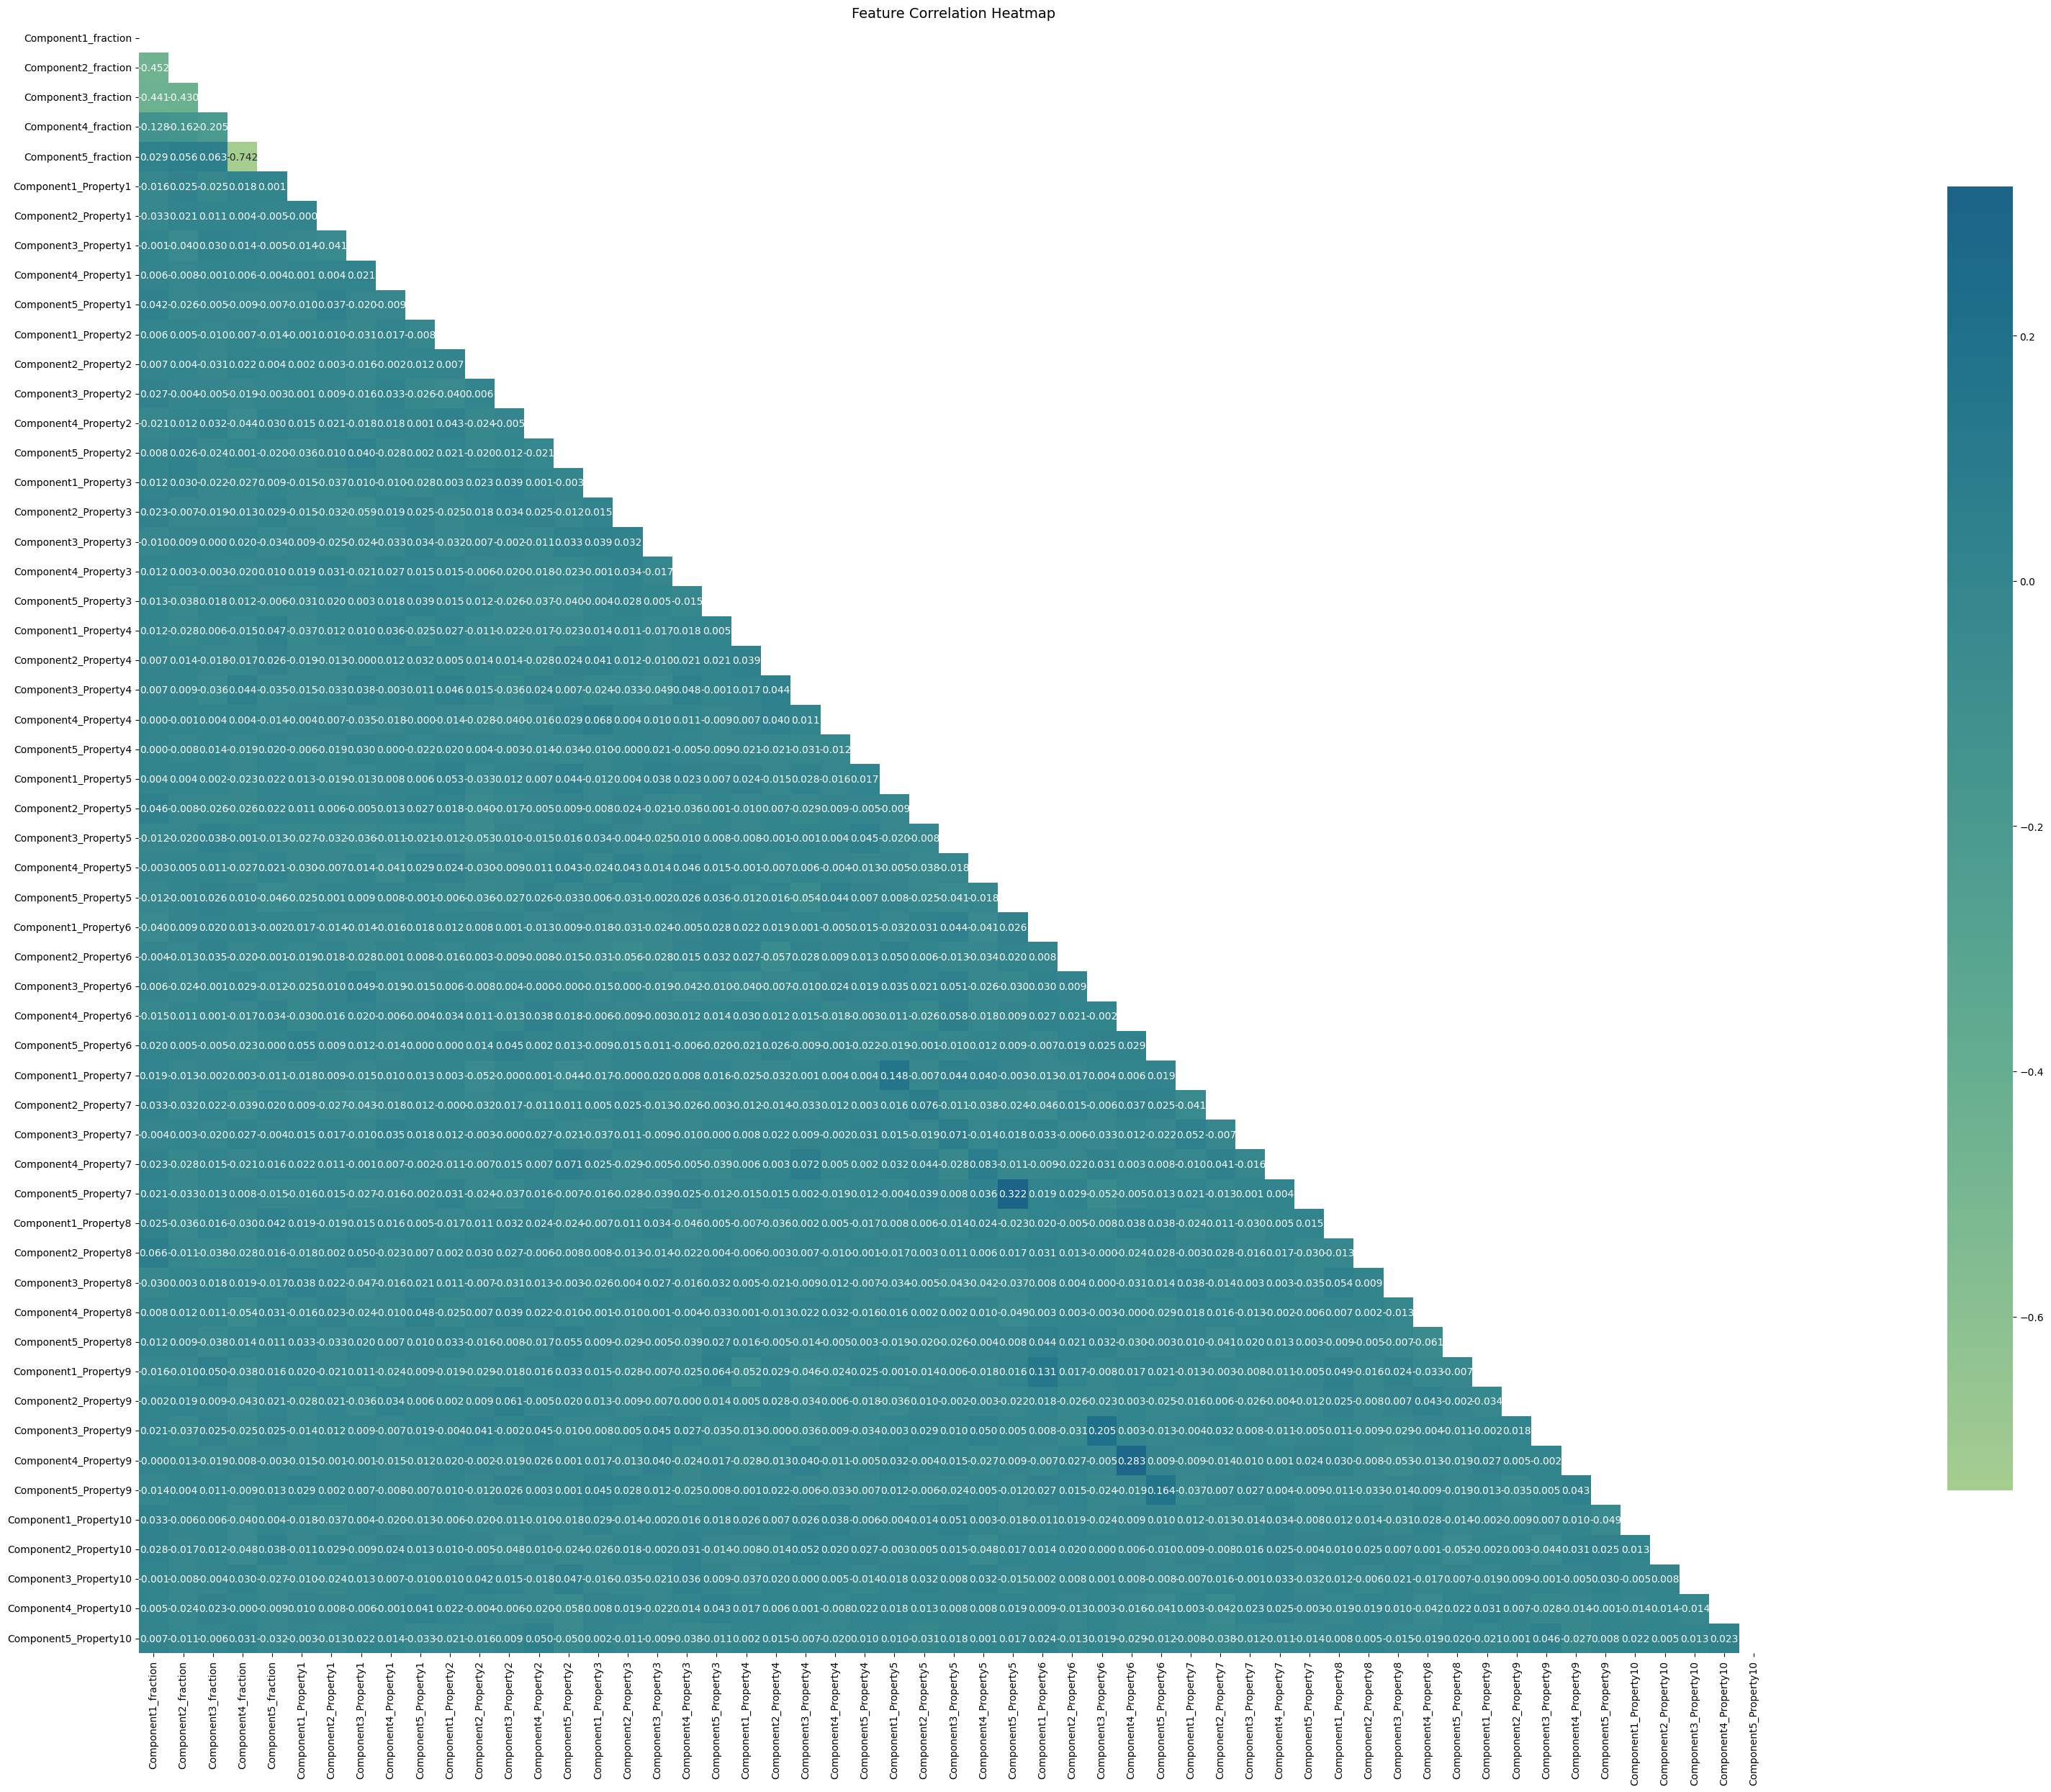

In [16]:
feature_correlation_matrix = X.corr()

plt.figure(figsize=(50, 25))
mask = np.triu(np.ones_like(feature_correlation_matrix, dtype=bool))

sns.heatmap(feature_correlation_matrix, 
            mask=mask,
            annot=True, 
            cmap='crest', 
            center=0,
            square=True, 
            fmt='.3f',
            cbar_kws={"shrink": .8})

plt.title('Feature Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

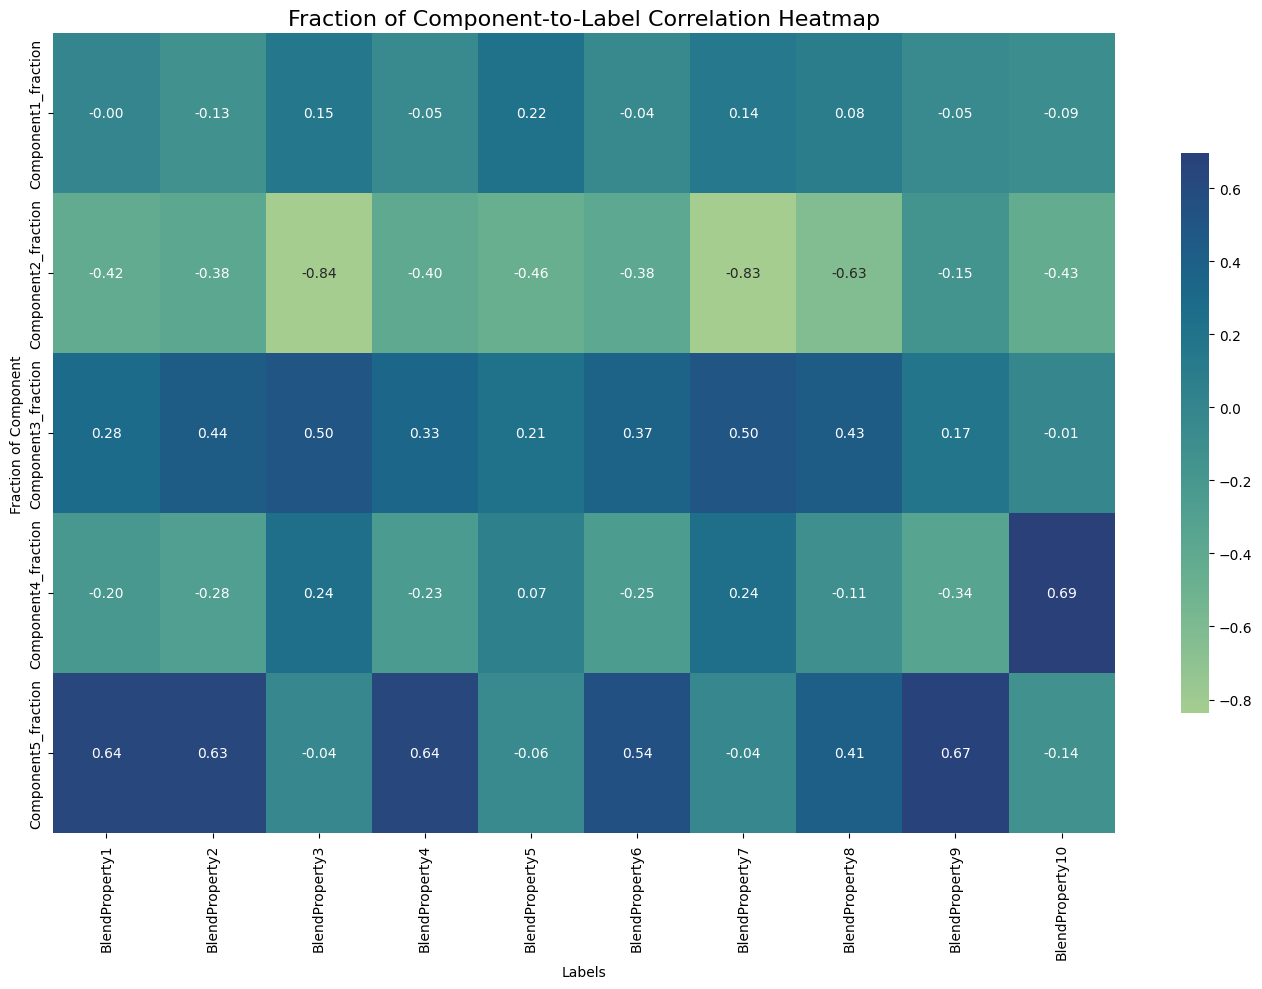

In [17]:
fractions = ['Component1_fraction', 'Component2_fraction', 'Component3_fraction', 'Component4_fraction', 'Component5_fraction', ]
fraction_corr = pd.DataFrame(index=fractions, columns=Y.columns)

for target in Y.columns:
    fraction_corr[target] = X[fractions].corrwith(Y[target])

fraction_corr = fraction_corr.astype(float)

plt.figure(figsize=(14, 10))
sns.heatmap(fraction_corr, annot=True, fmt=".2f", cmap="crest", center=0, cbar_kws={"shrink": 0.7})
plt.title("Fraction of Component-to-Label Correlation Heatmap", fontsize=16)
plt.xlabel("Labels")
plt.ylabel("Fraction of Component")
plt.tight_layout()
plt.show()

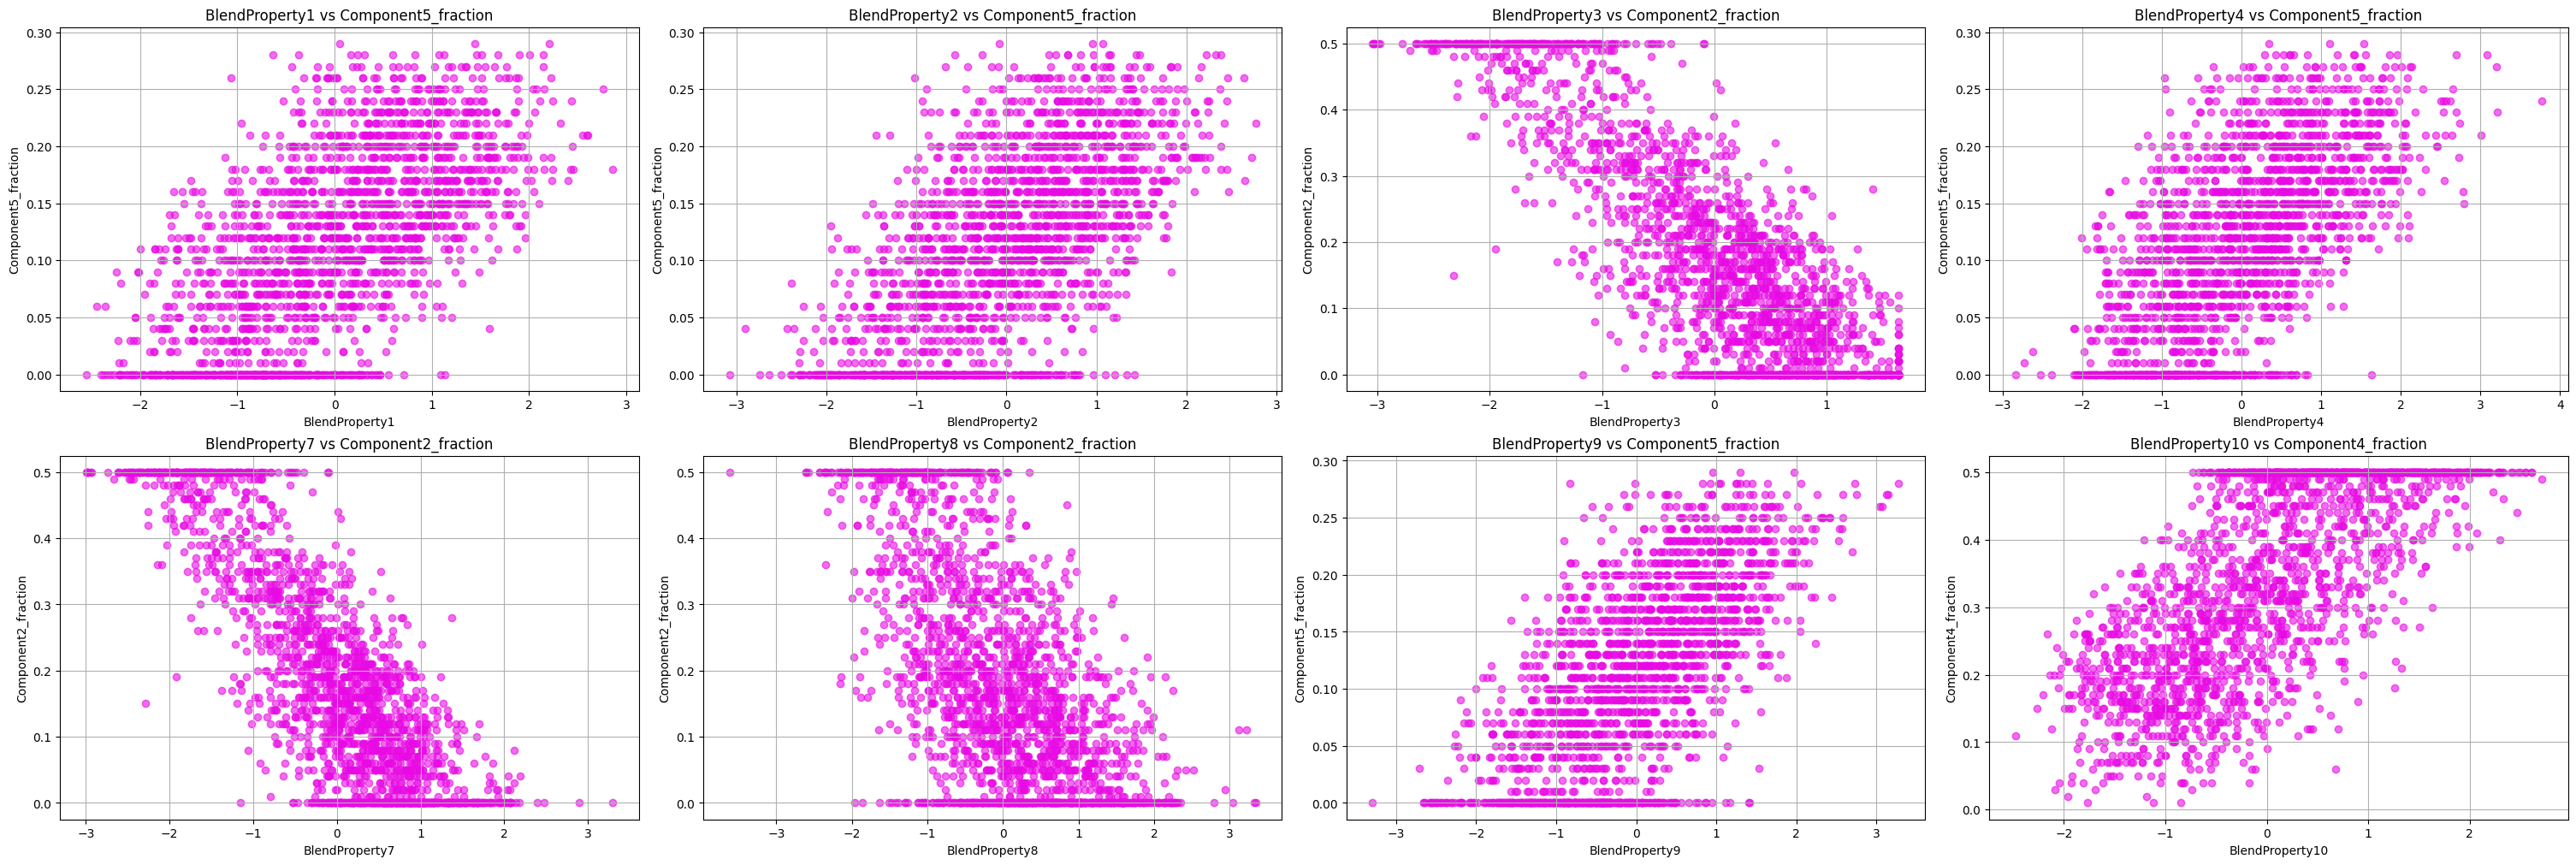

In [18]:
scattercorel(trainData, ['BlendProperty1', 'BlendProperty2', 'BlendProperty3', 'BlendProperty4', 'BlendProperty7', 'BlendProperty8', 'BlendProperty9', 'BlendProperty10'], 
             ['Component5_fraction', 'Component5_fraction', 'Component2_fraction', 'Component5_fraction', 'Component2_fraction', 'Component2_fraction', 'Component5_fraction', 'Component4_fraction'],
             figsize=(30, 10))

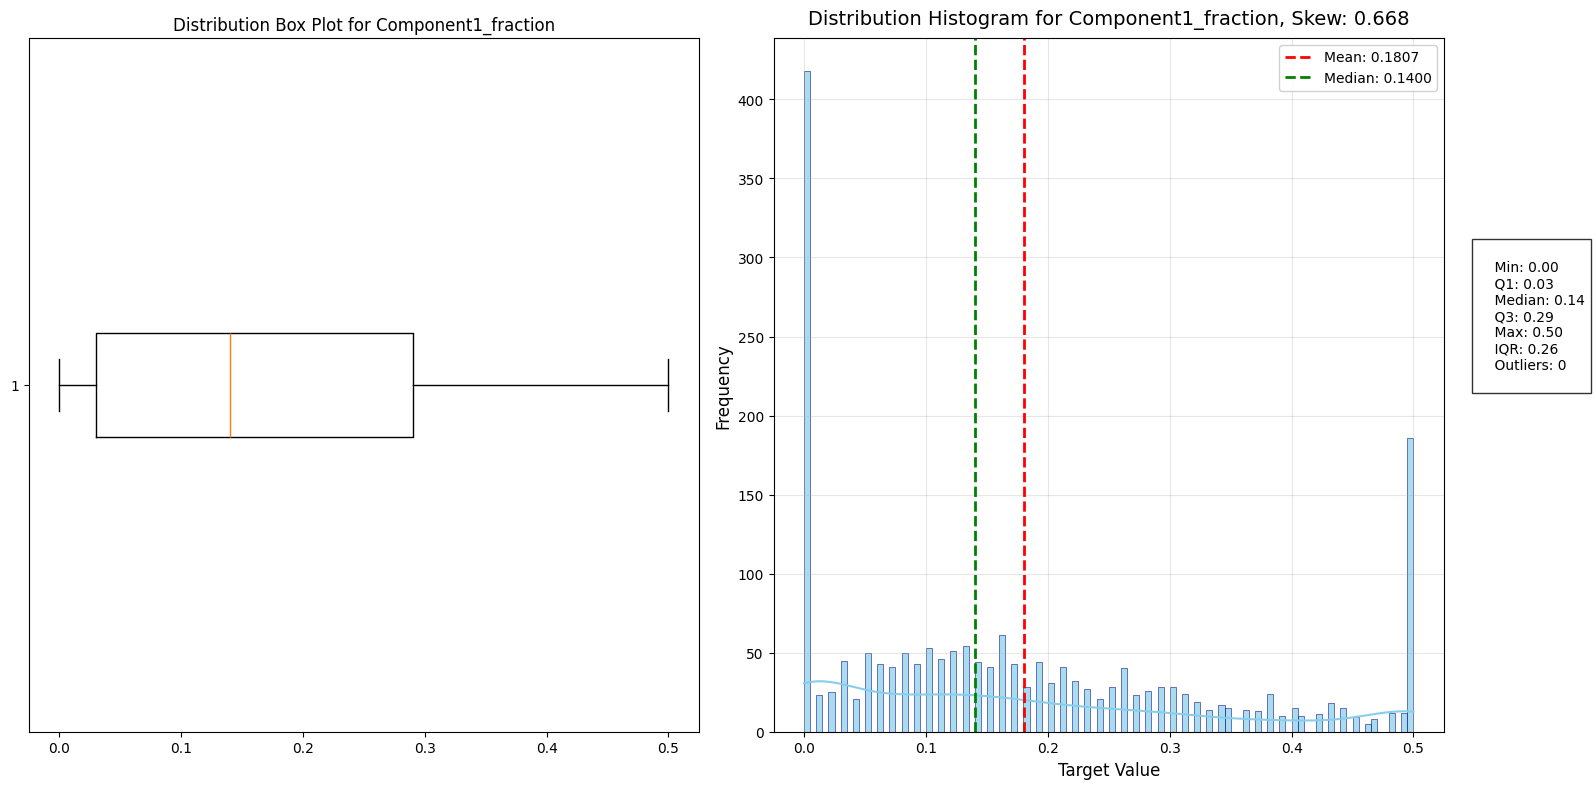

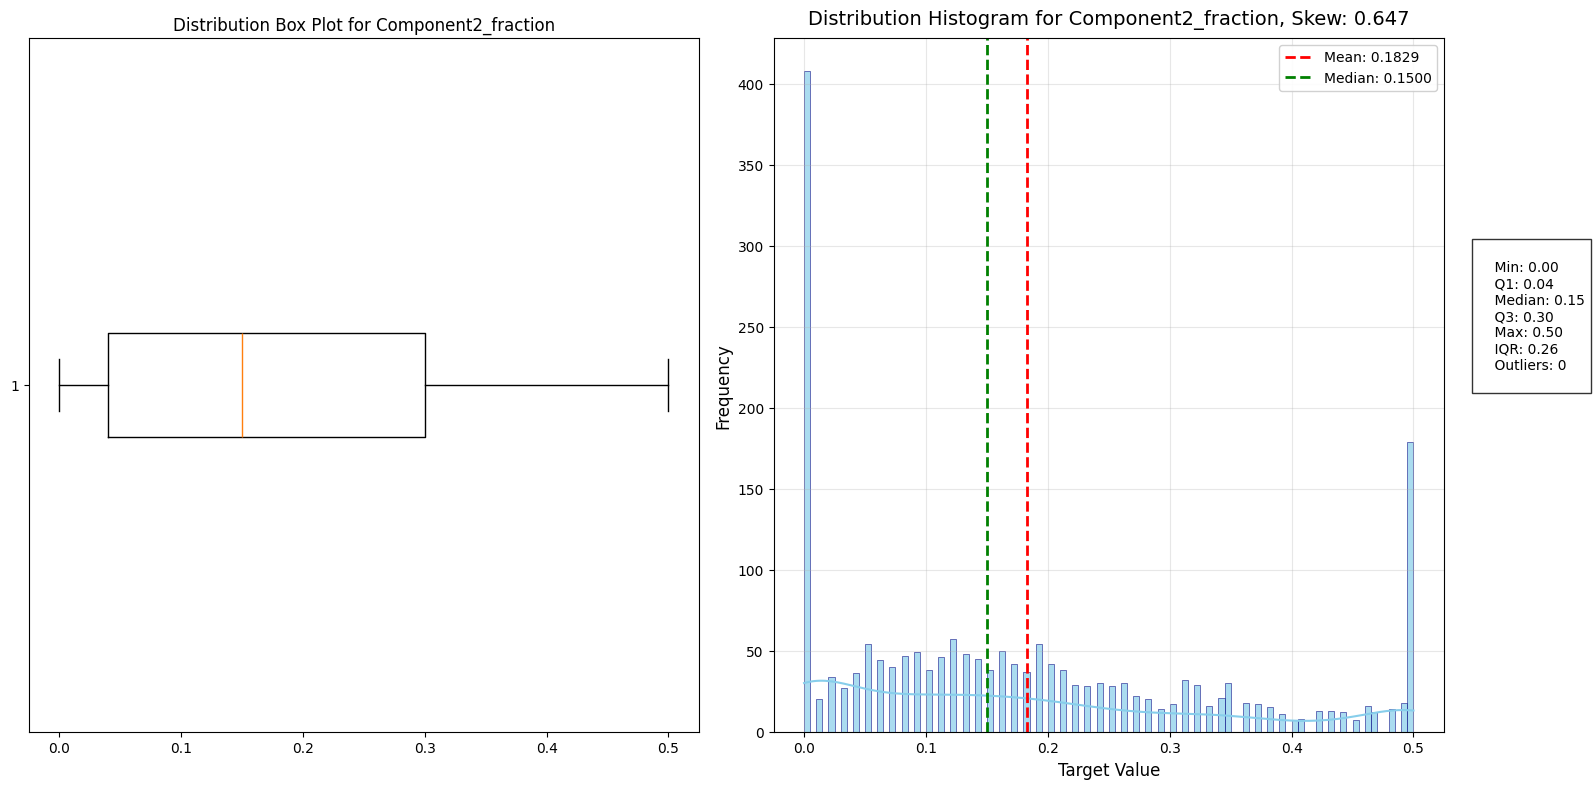

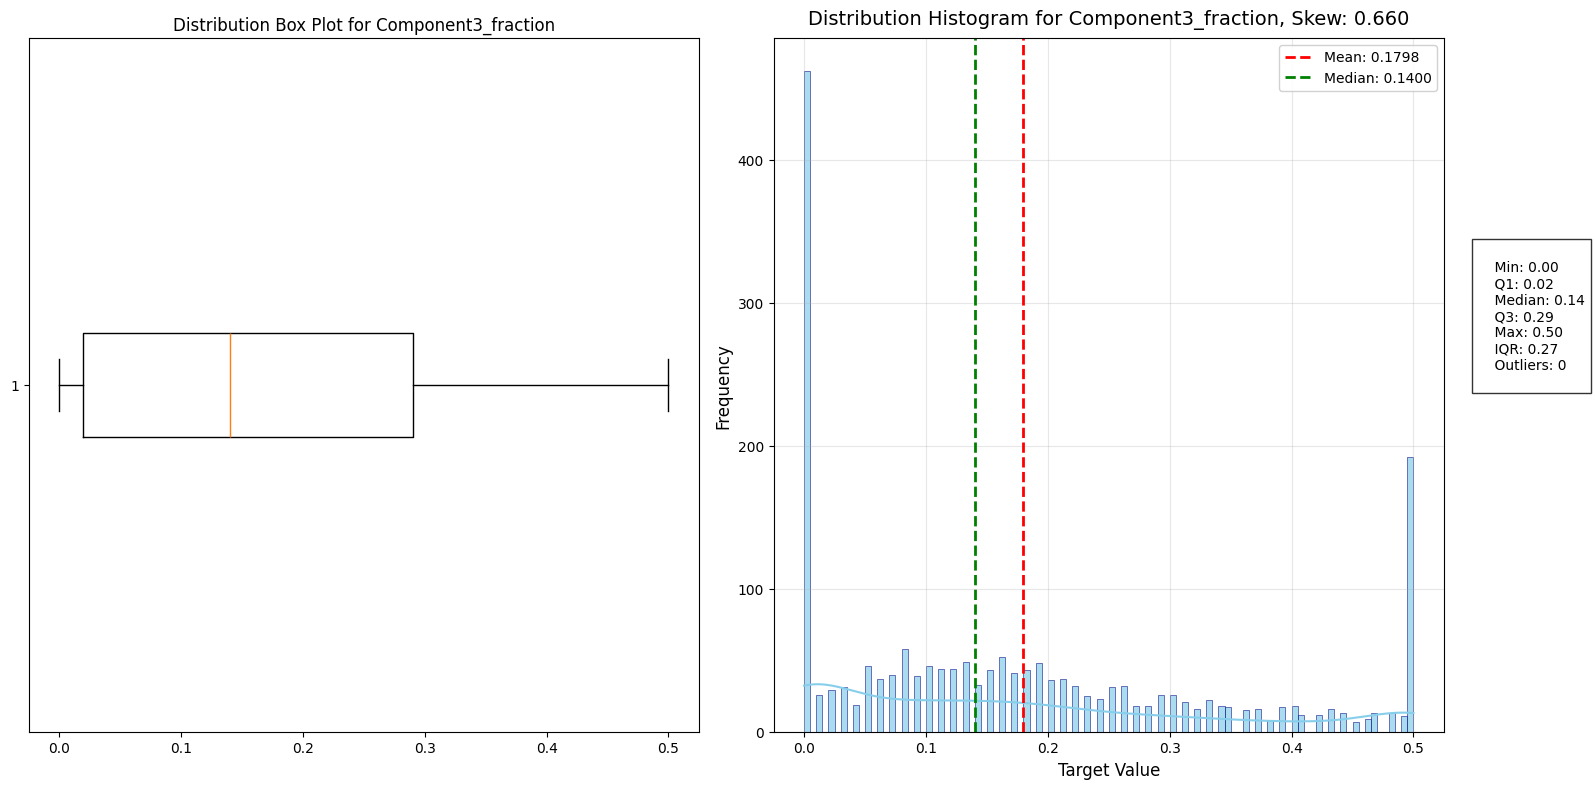

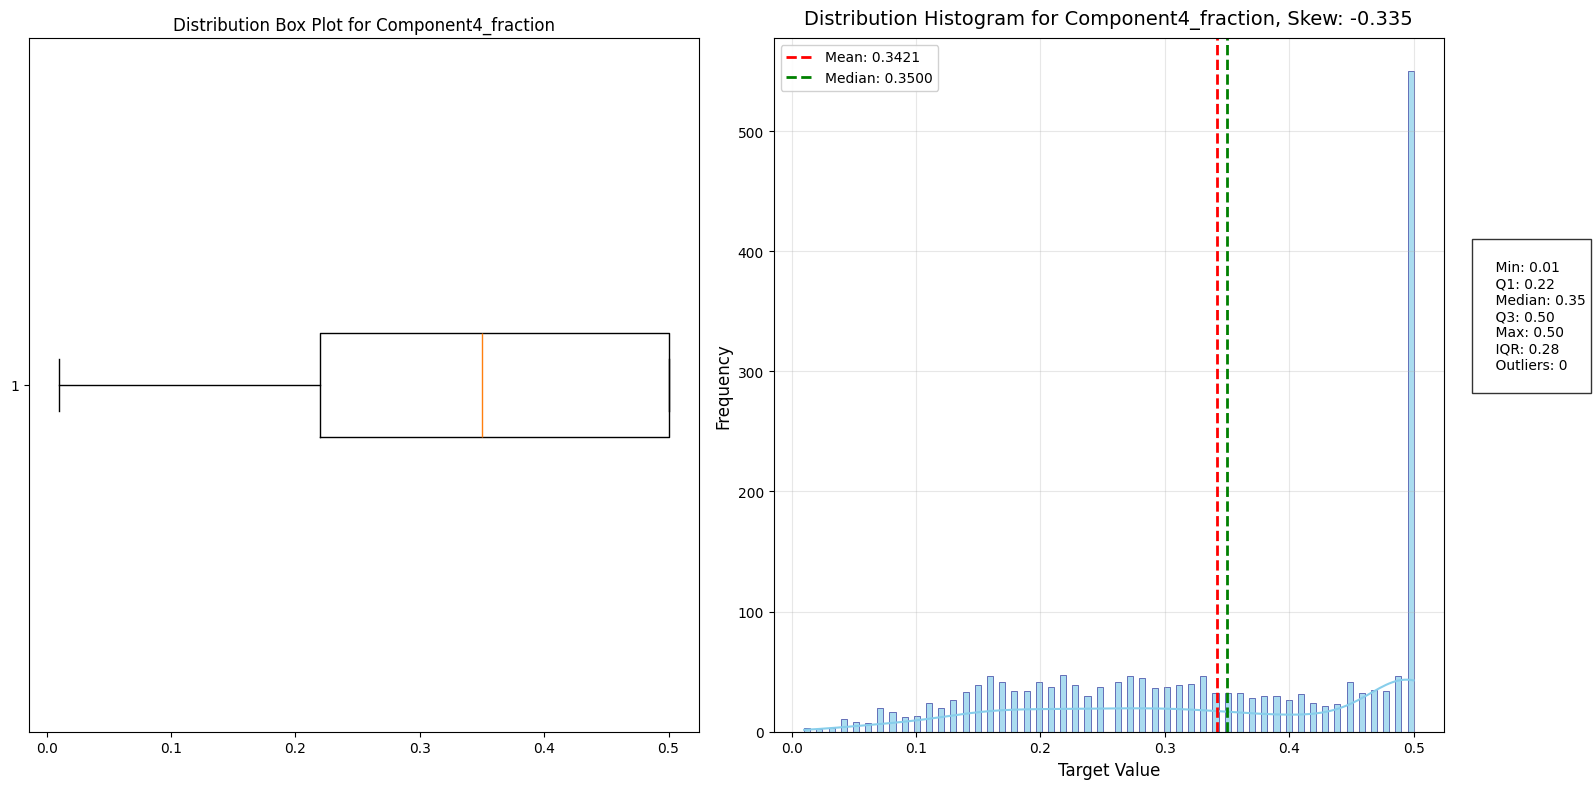

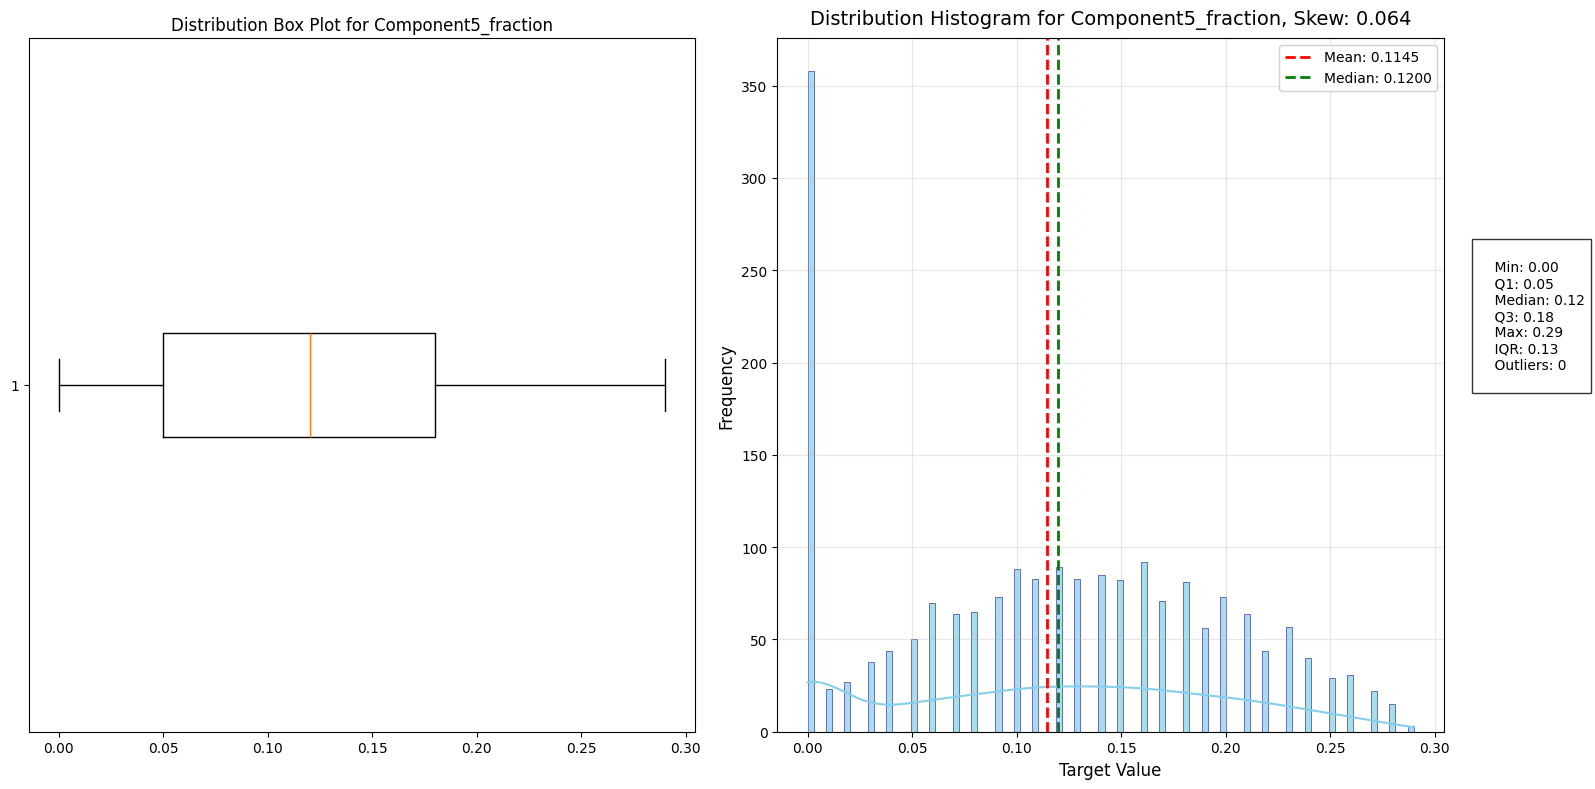

In [19]:
for component in fractions:
    outskew(X, component)

In [20]:
X.isna().sum()

Component1_fraction      0
Component2_fraction      0
Component3_fraction      0
Component4_fraction      0
Component5_fraction      0
Component1_Property1     0
Component2_Property1     0
Component3_Property1     0
Component4_Property1     0
Component5_Property1     0
Component1_Property2     0
Component2_Property2     0
Component3_Property2     0
Component4_Property2     0
Component5_Property2     0
Component1_Property3     0
Component2_Property3     0
Component3_Property3     0
Component4_Property3     0
Component5_Property3     0
Component1_Property4     0
Component2_Property4     0
Component3_Property4     0
Component4_Property4     0
Component5_Property4     0
Component1_Property5     0
Component2_Property5     0
Component3_Property5     0
Component4_Property5     0
Component5_Property5     0
Component1_Property6     0
Component2_Property6     0
Component3_Property6     0
Component4_Property6     0
Component5_Property6     0
Component1_Property7     0
Component2_Property7     0
C

## Checking Distribution of synthetic Data

In [34]:
from sdv.single_table import GaussianCopulaSynthesizer
from sdv.metadata import SingleTableMetadata

metadata = SingleTableMetadata()
metadata.detect_from_dataframe(trainData)
synthesizer = GaussianCopulaSynthesizer(metadata=metadata)

synthesizer.fit(trainData)
synData= synthesizer.sample(2000)

c:\Users\LENOVO\AppData\Local\Programs\Python\Python311\Lib\site-packages\sdv\single_table\base.py:163: FutureWarning:

The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.

c:\Users\LENOVO\AppData\Local\Programs\Python\Python311\Lib\site-packages\sdv\single_table\base.py:129: UserWarning:

We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.



In [35]:
synData

,Component1_fraction,Component2_fraction,Component3_fraction,Component4_fraction,Component5_fraction,Component1_Property1,Component2_Property1,Component3_Property1,Component4_Property1,Component5_Property1,...,BlendProperty1,BlendProperty2,BlendProperty3,BlendProperty4,BlendProperty5,BlendProperty6,BlendProperty7,BlendProperty8,BlendProperty9,BlendProperty10
0,0.38,0.22,0.33,0.23,0.19,0.057509,-1.663265,0.420493,-0.970050,0.819578,...,0.826268,1.694889,0.167707,2.098054,-0.471893,0.853947,0.341705,0.774673,0.589734,1.005606
1,0.17,0.08,0.26,0.30,0.18,0.612746,-0.065515,-0.353789,0.293525,0.462603,...,1.285910,0.656493,-0.030484,0.532327,-0.196489,0.286034,0.255527,0.891685,1.047155,-0.423289
2,0.48,0.03,0.46,0.08,0.24,0.346670,2.340332,-0.414106,0.079514,0.192272,...,1.746131,0.425295,1.007749,0.805693,0.729780,1.658414,0.955877,0.961141,-0.186345,-0.274350
3,0.05,0.43,0.50,0.41,0.14,0.320847,-0.024441,0.177551,1.184112,-1.617885,...,0.642784,2.013381,0.701181,0.040738,-1.434120,0.160610,0.805868,0.625882,0.001121,1.224466
4,0.44,0.03,0.38,0.43,0.07,-0.247084,-1.180424,0.976742,0.278323,0.800582,...,0.660171,0.880091,0.798561,-0.411064,0.465844,-1.140293,0.931432,0.157948,-0.296138,1.002397
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,0.48,0.17,0.07,0.10,0.15,-0.449019,-0.430861,-0.293253,-2.093426,0.545863,...,-1.070053,-0.612921,-0.428070,-0.033391,-0.105174,-0.128938,-0.507709,0.039380,-0.164390,-0.664981
1996,0.12,0.02,0.40,0.42,0.14,0.235871,1.110862,-0.735102,-0.113460,-1.773981,...,1.344441,0.903377,0.793984,0.884020,-0.120582,0.782833,0.733421,0.516214,0.865794,1.397212
1997,0.32,0.06,0.21,0.50,0.01,0.697372,-0.499928,-0.199287,-0.669036,0.382756,...,-1.580801,-0.941272,0.325538,-1.350710,0.724223,-0.617752,0.277728,-1.642169,-0.447300,0.575388
1998,0.04,0.13,0.44,0.44,0.08,0.219403,0.409644,-1.678369,-0.130597,0.386507,...,-0.253661,0.093849,1.123456,1.109672,-0.587429,1.086267,0.927773,-0.372840,-0.789924,1.242766


## Synthetic Data Feature Analysis

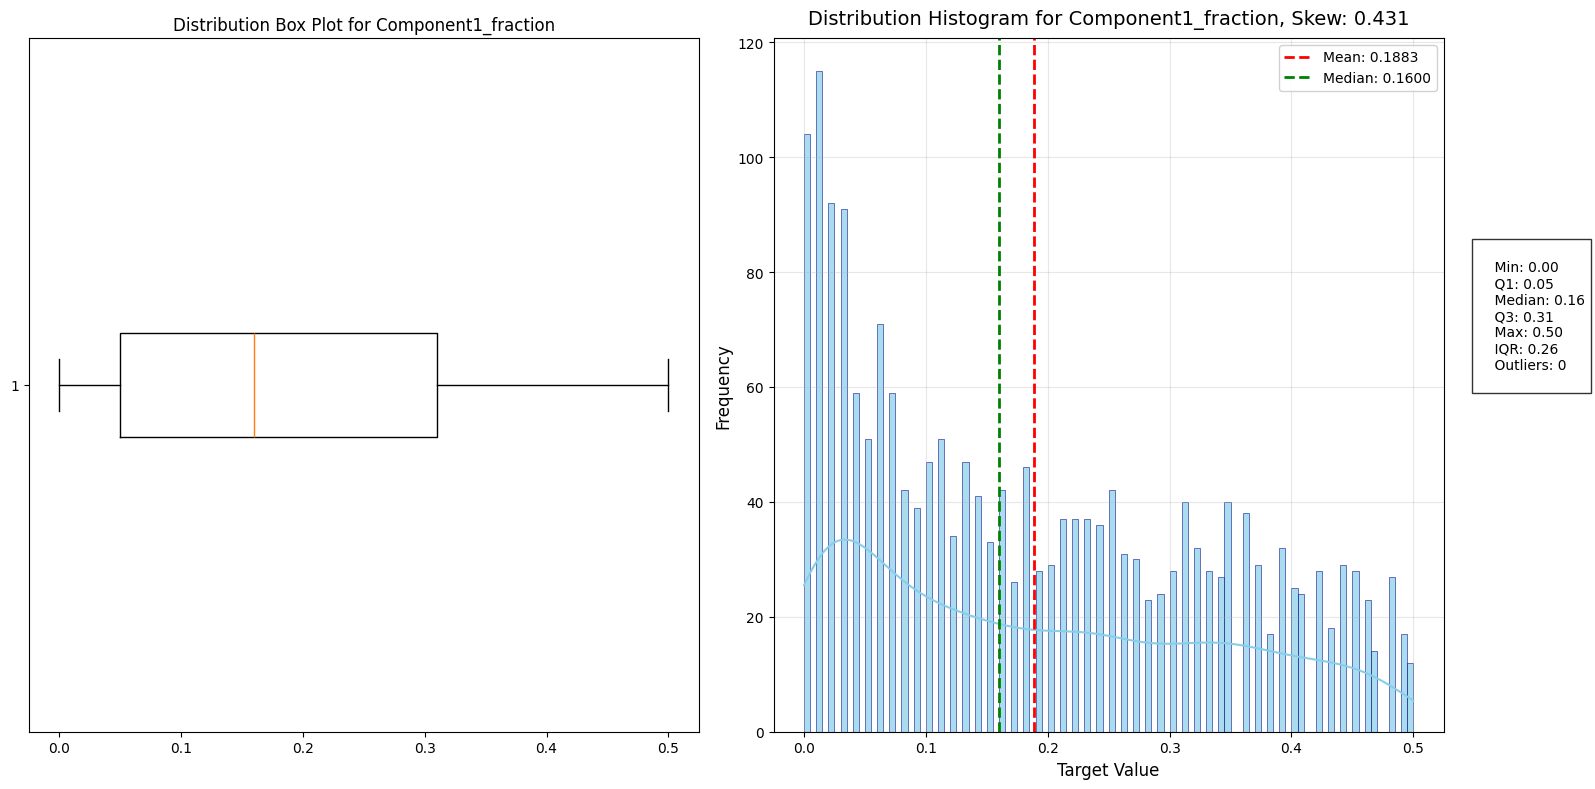

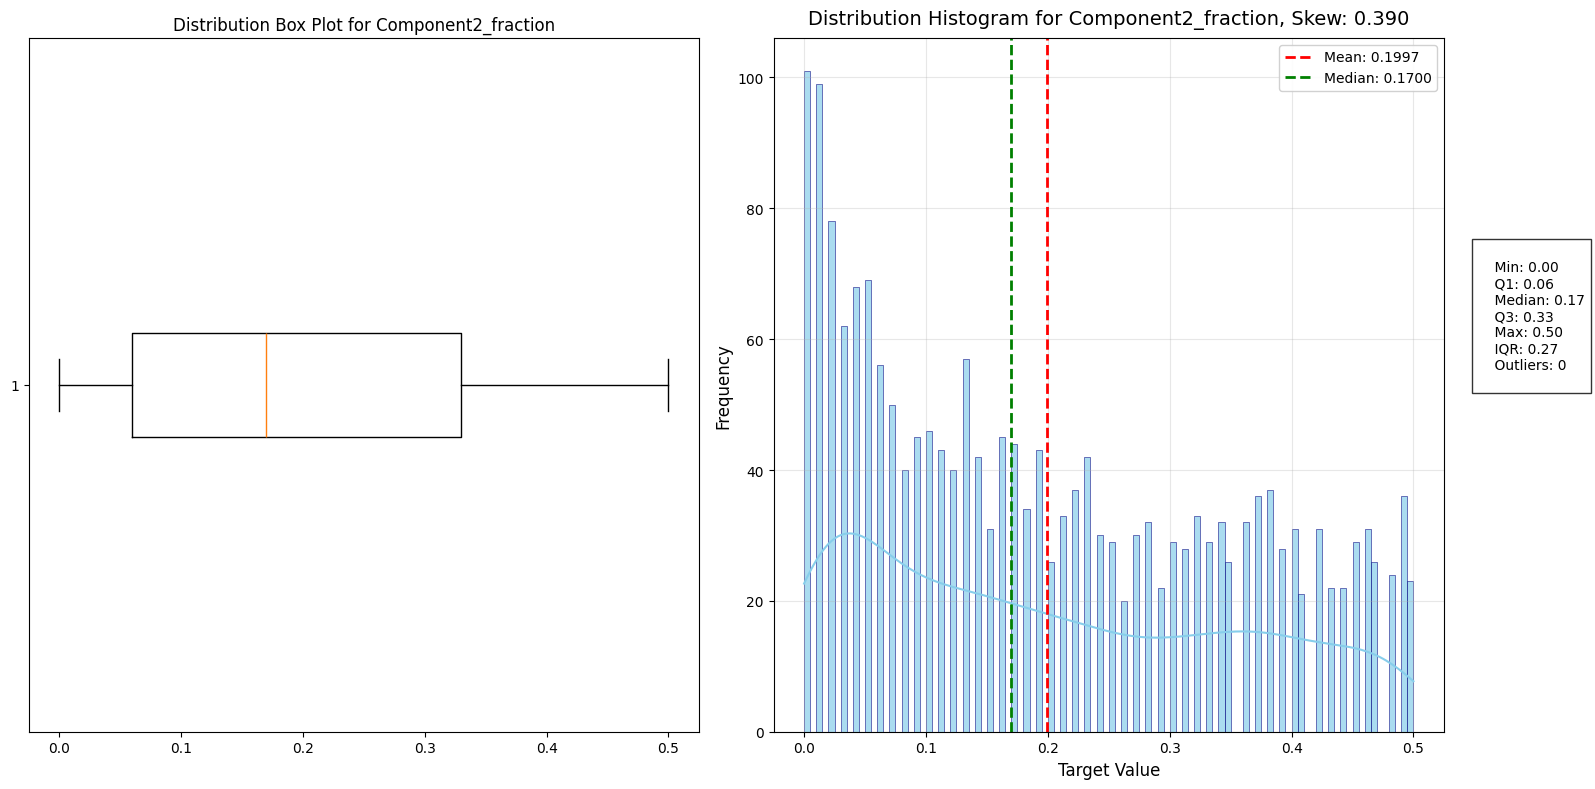

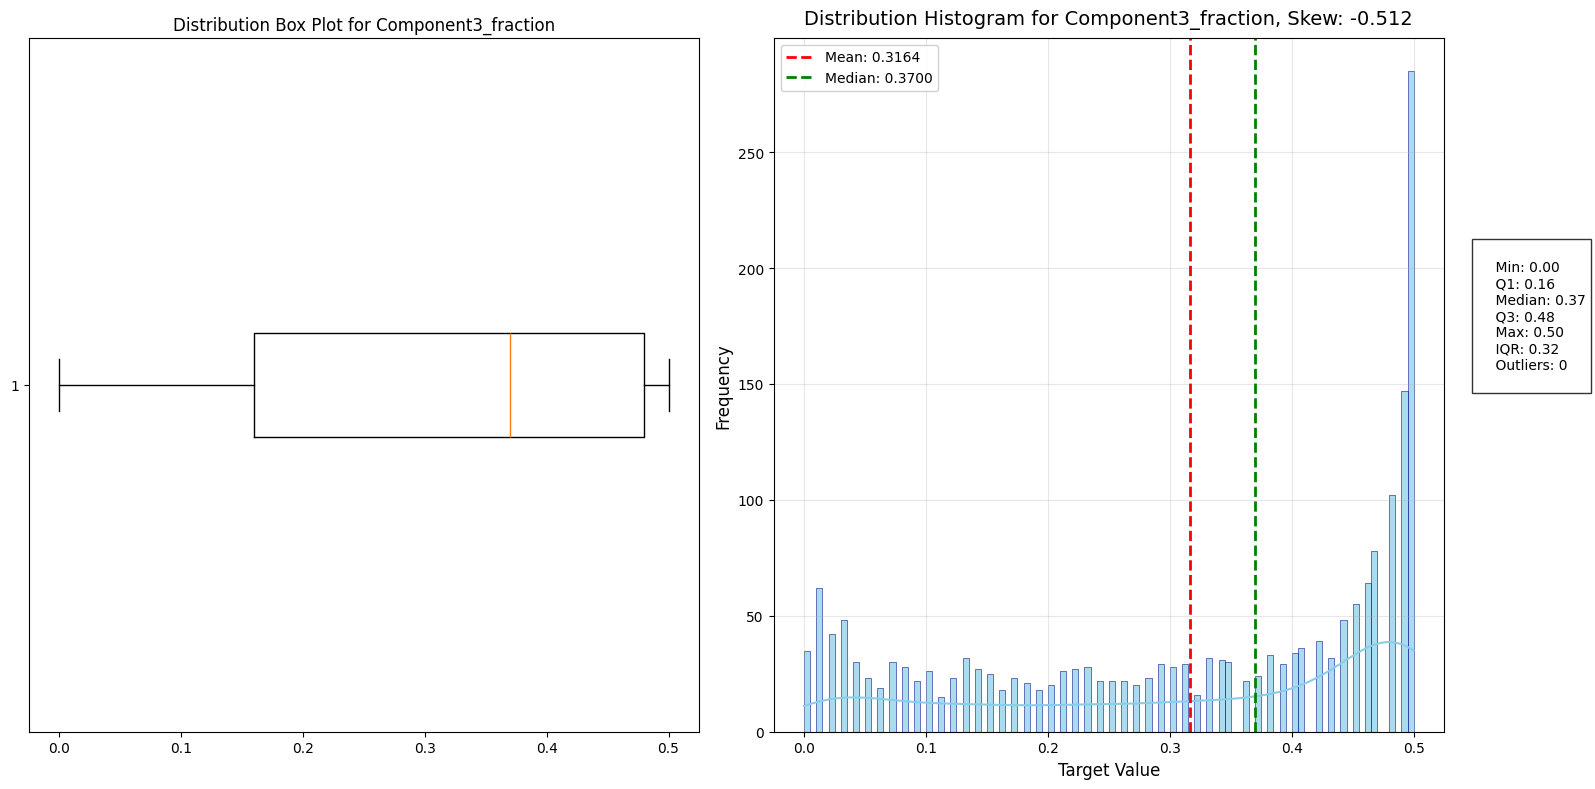

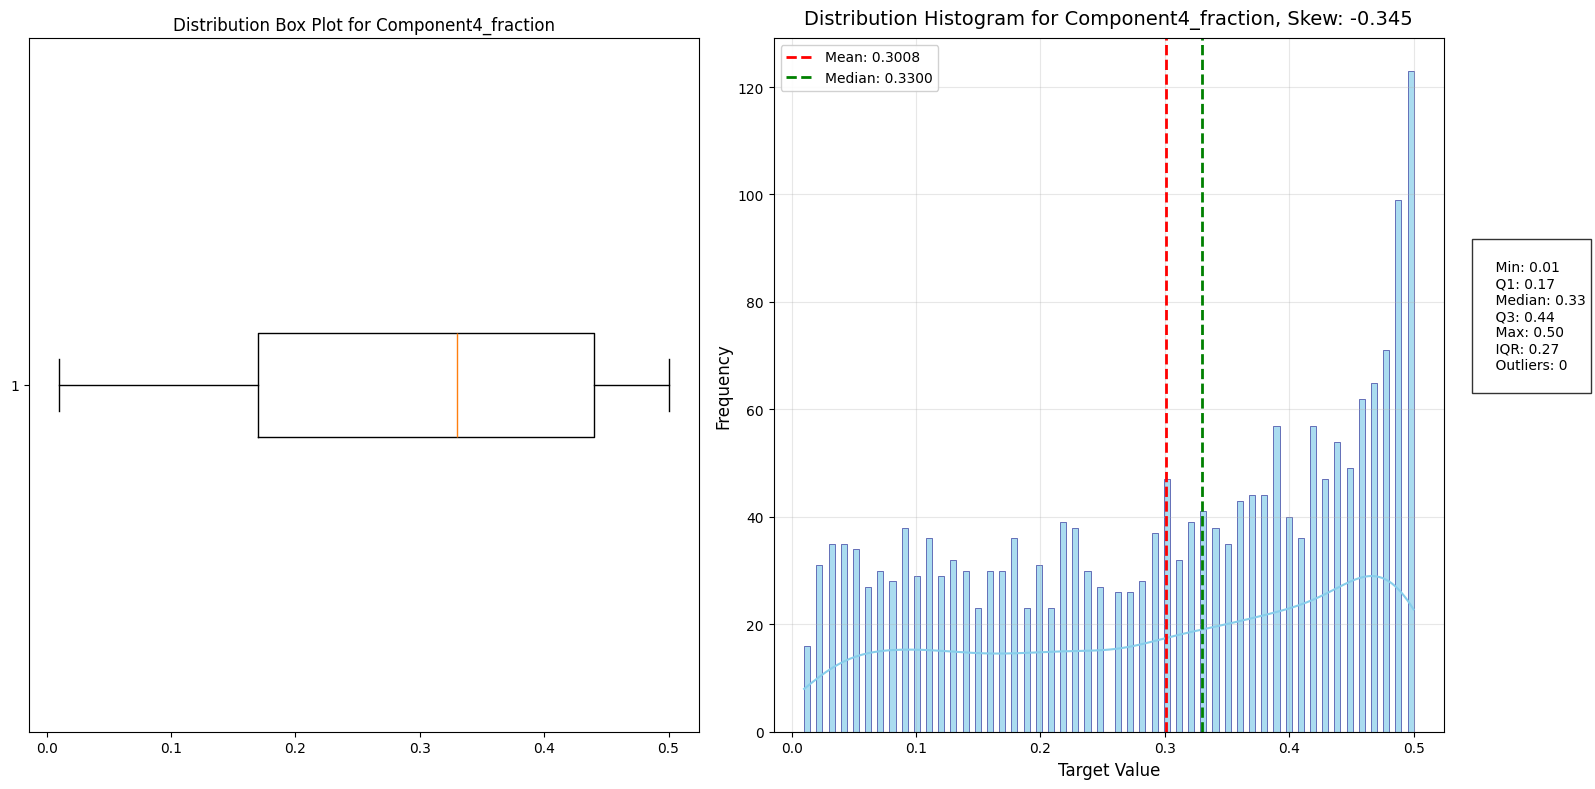

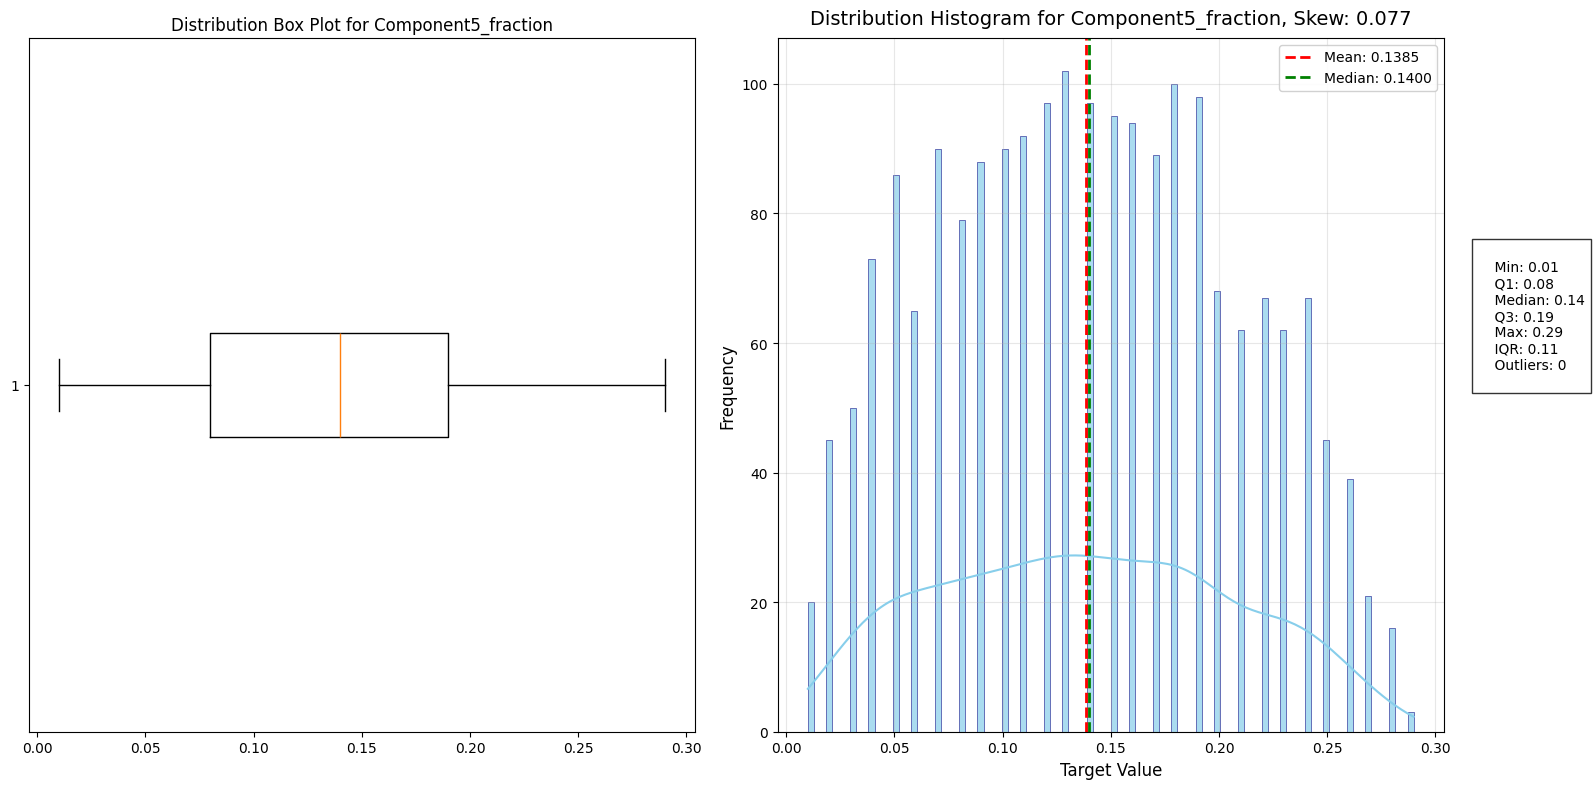

In [36]:
for component in fractions:
    outskew(synData, component)

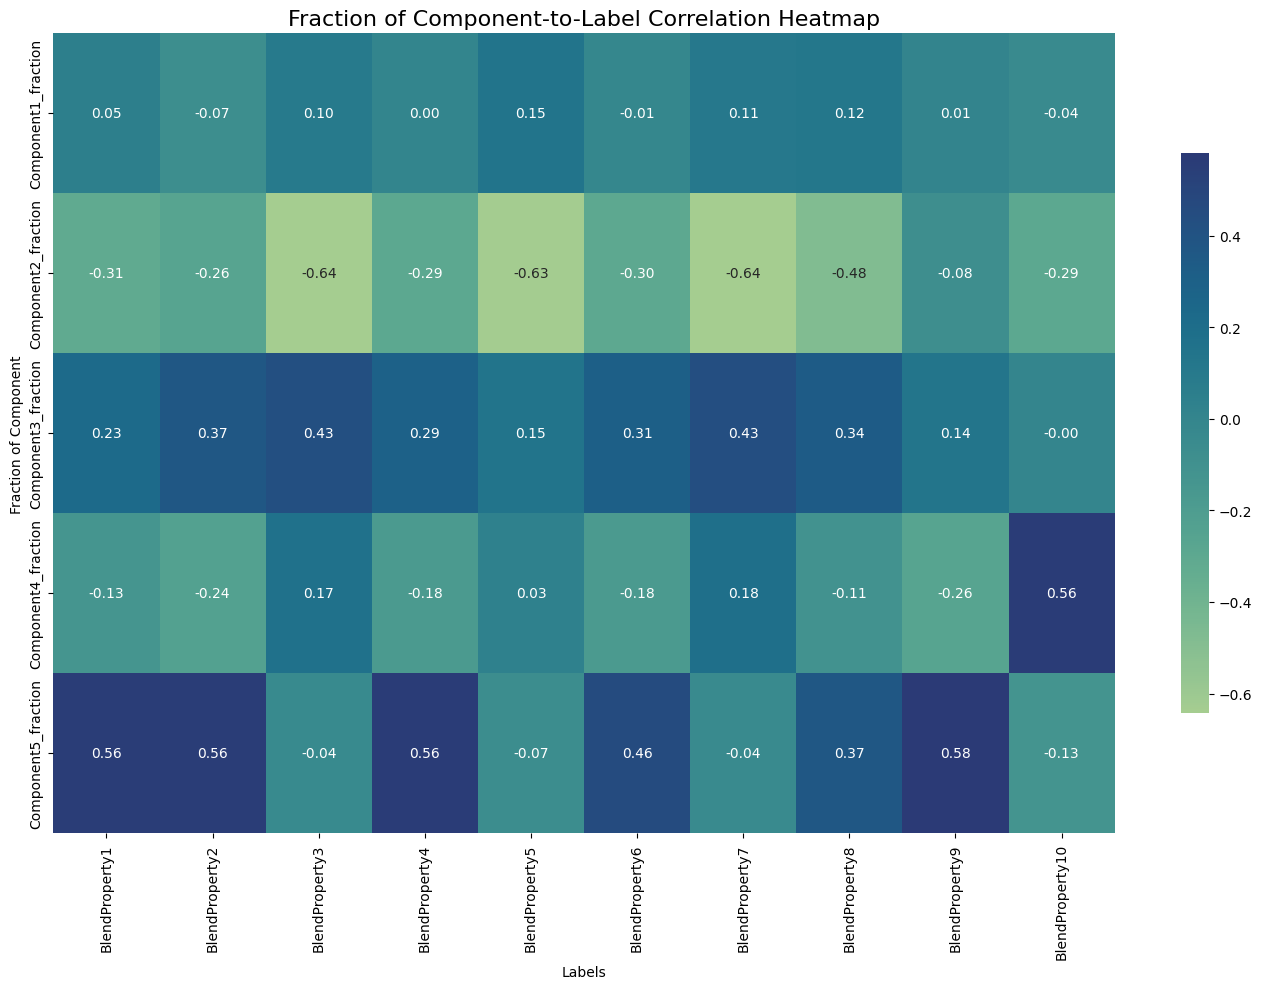

In [37]:
fractions = ['Component1_fraction', 'Component2_fraction', 'Component3_fraction', 'Component4_fraction', 'Component5_fraction', ]
fraction_corr = pd.DataFrame(index=fractions, columns=synData[targeColumns].columns)

for target in synData[targeColumns].columns:
    fraction_corr[target] = synData[fractions].corrwith(synData[target])

fraction_corr = fraction_corr.astype(float)

plt.figure(figsize=(14, 10))
sns.heatmap(fraction_corr, annot=True, fmt=".2f", cmap="crest", center=0, cbar_kws={"shrink": 0.7})
plt.title("Fraction of Component-to-Label Correlation Heatmap", fontsize=16)
plt.xlabel("Labels")
plt.ylabel("Fraction of Component")
plt.tight_layout()
plt.show()

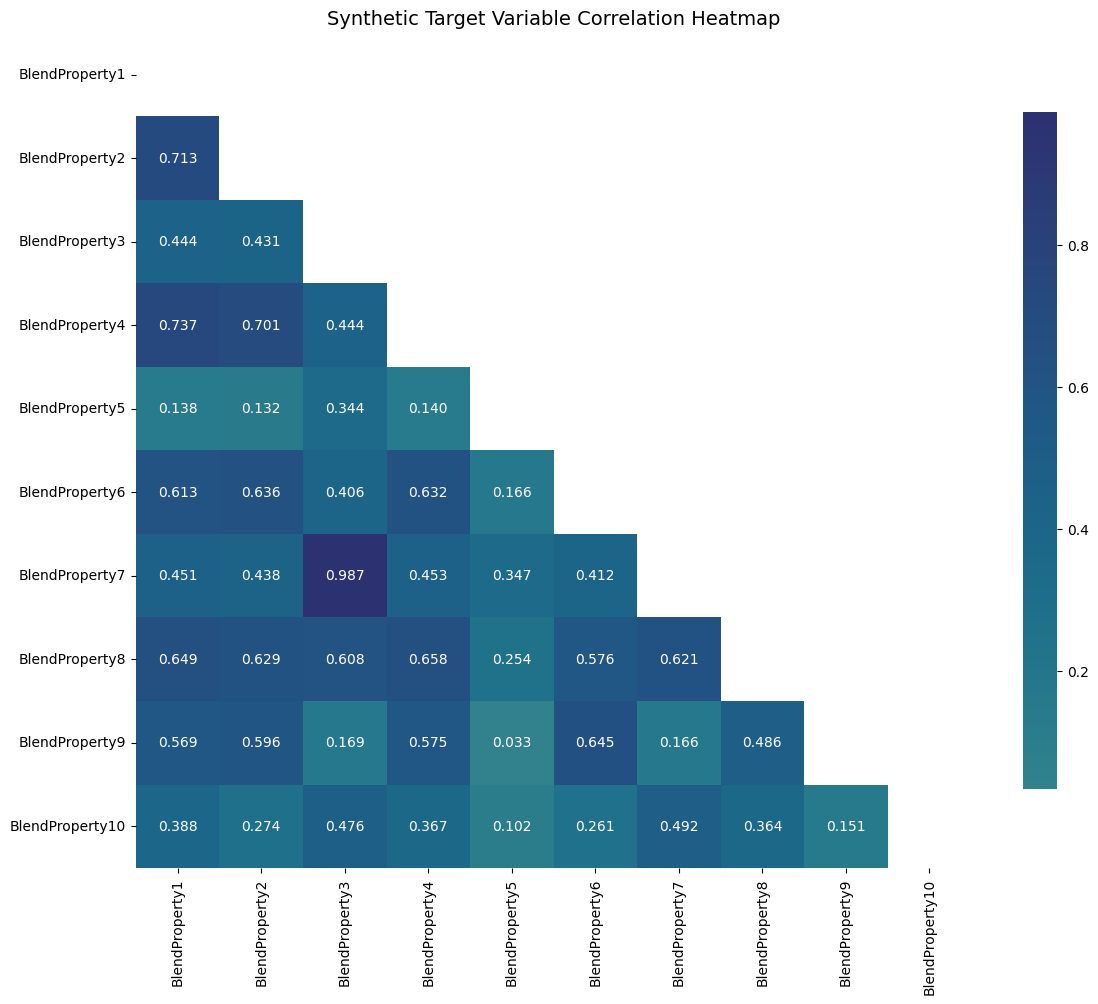

In [38]:
synlabel_correlation_matrix = synData[targeColumns].corr()

plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(synlabel_correlation_matrix, dtype=bool))

sns.heatmap(synlabel_correlation_matrix, 
            mask=mask,
            annot=True, 
            cmap='crest', 
            center=0,
            square=True, 
            fmt='.3f',
            cbar_kws={"shrink": .8})

plt.title('Synthetic Target Variable Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

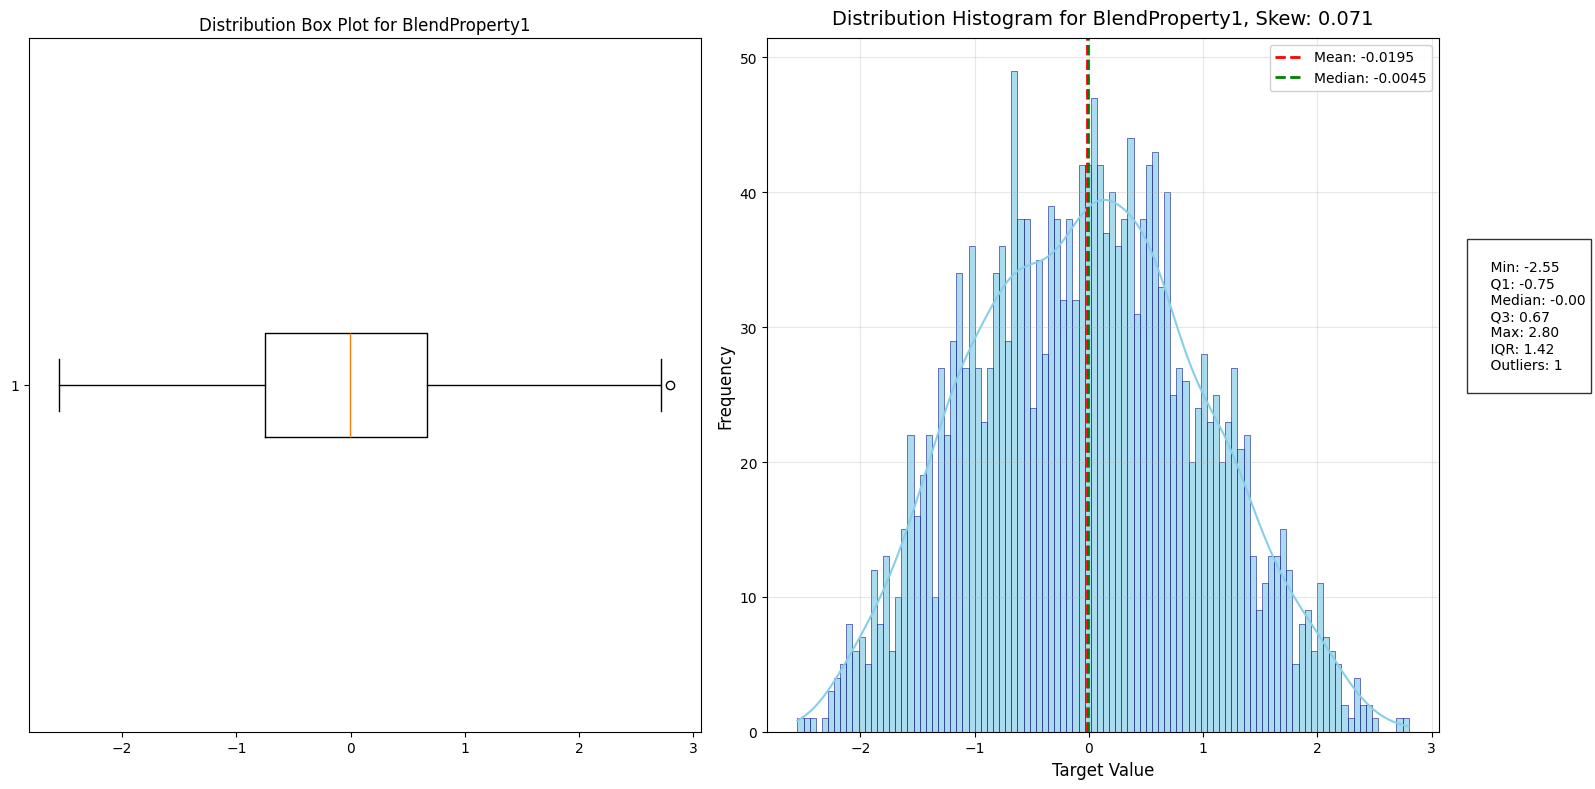

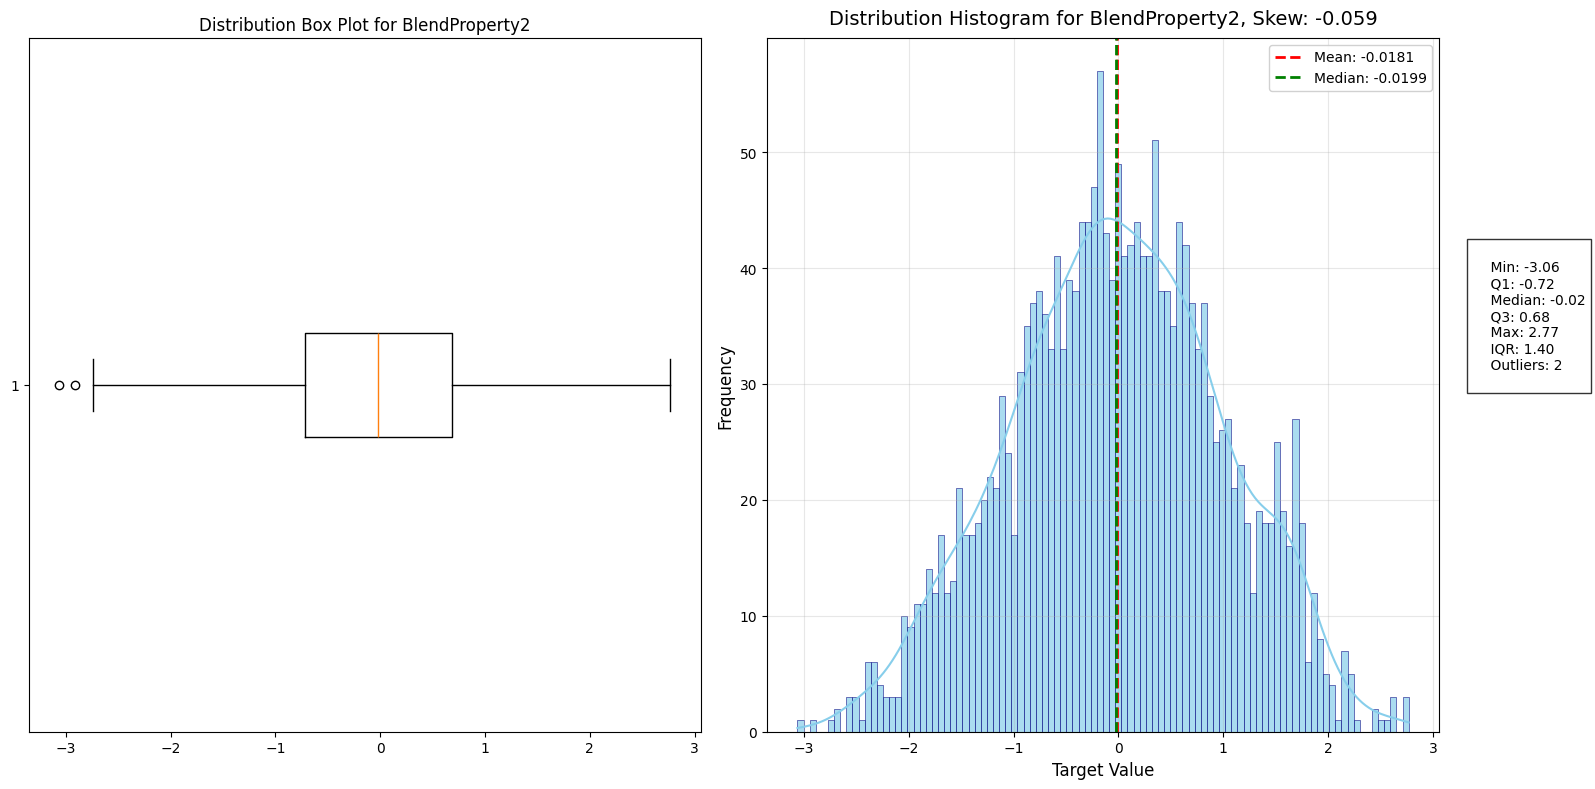

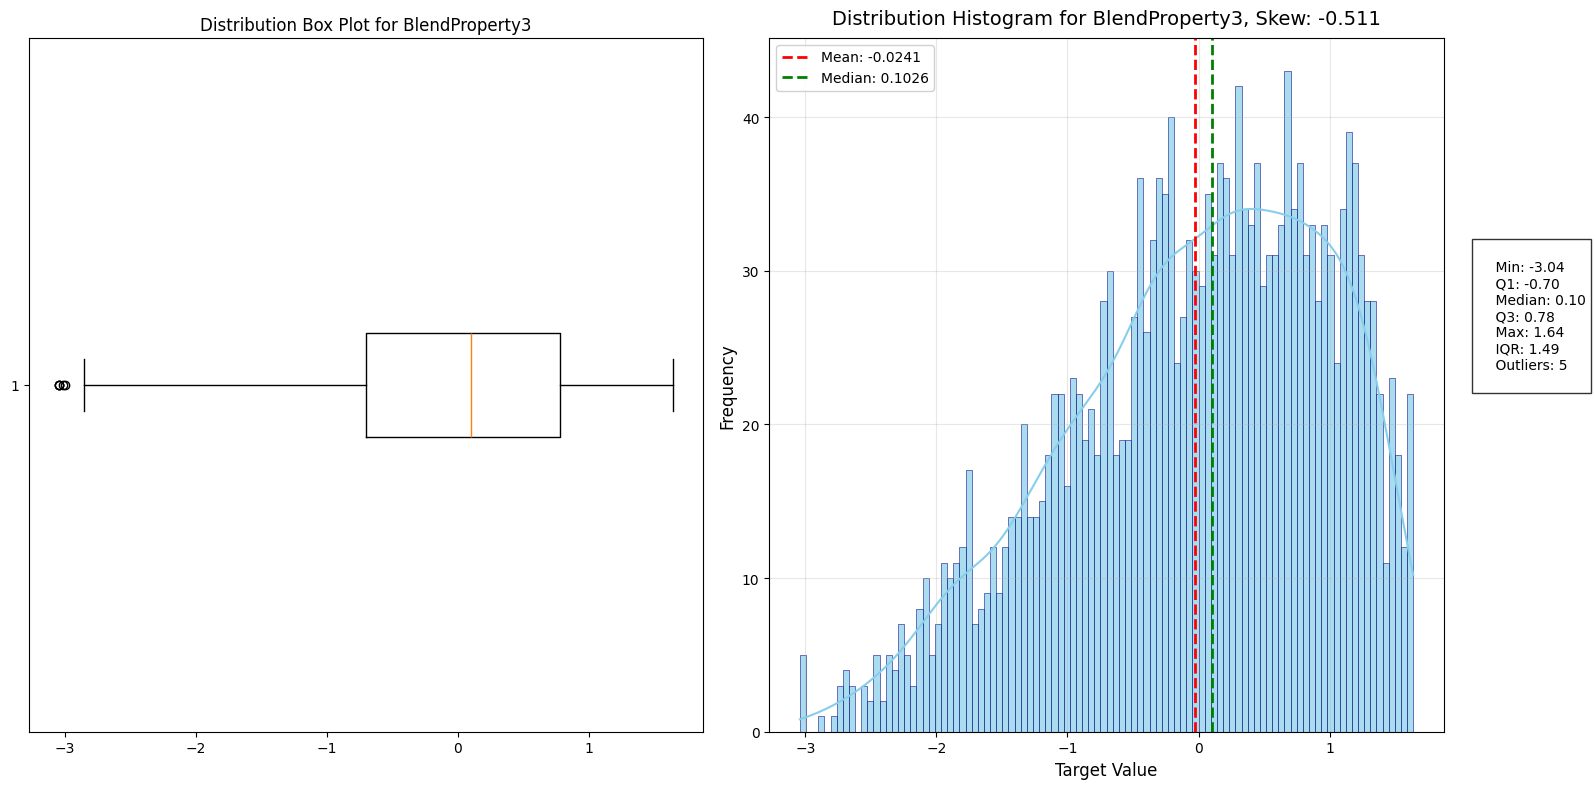

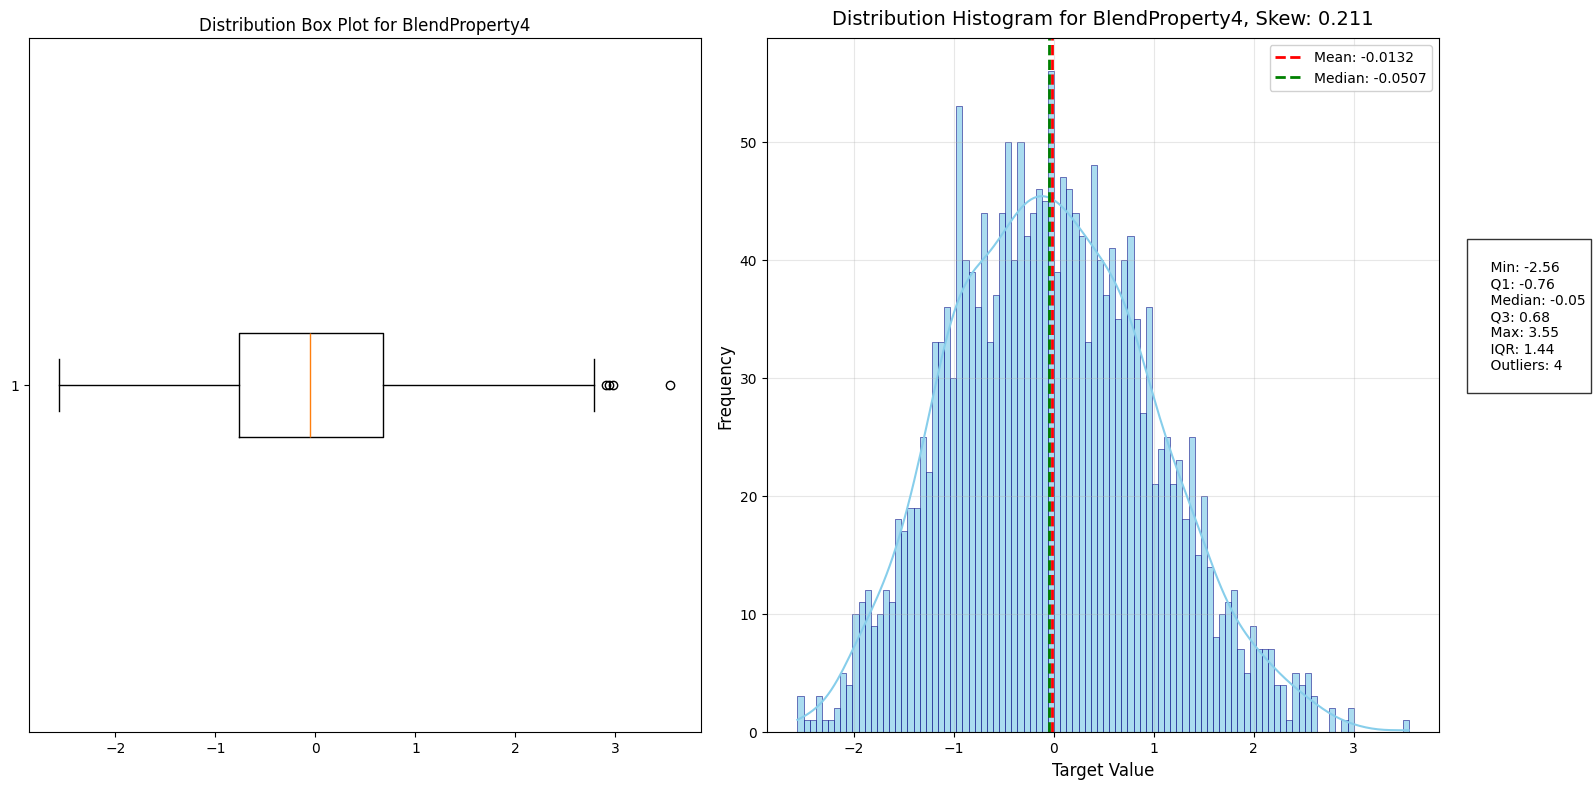

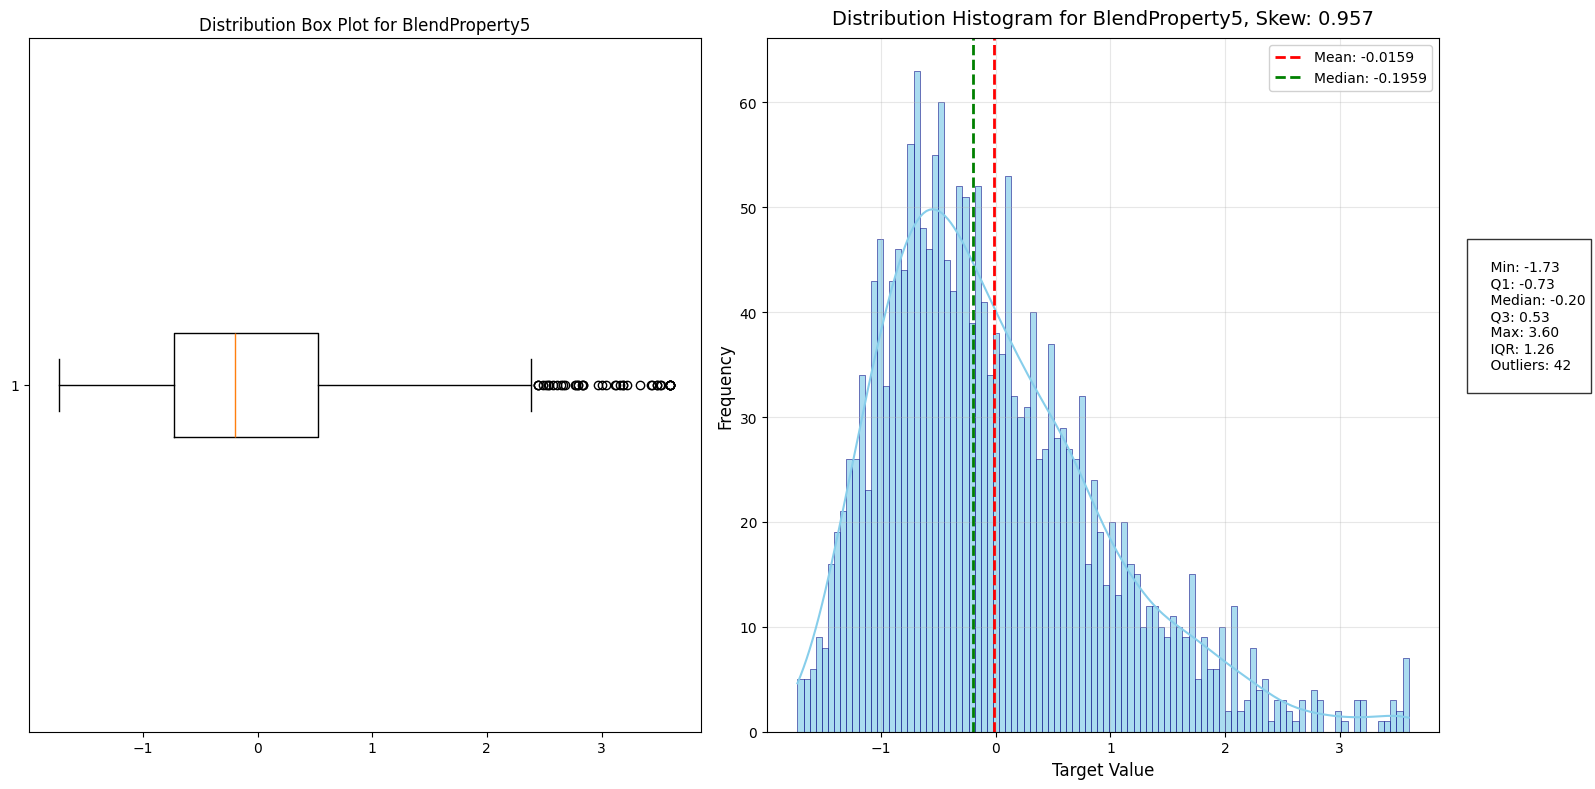

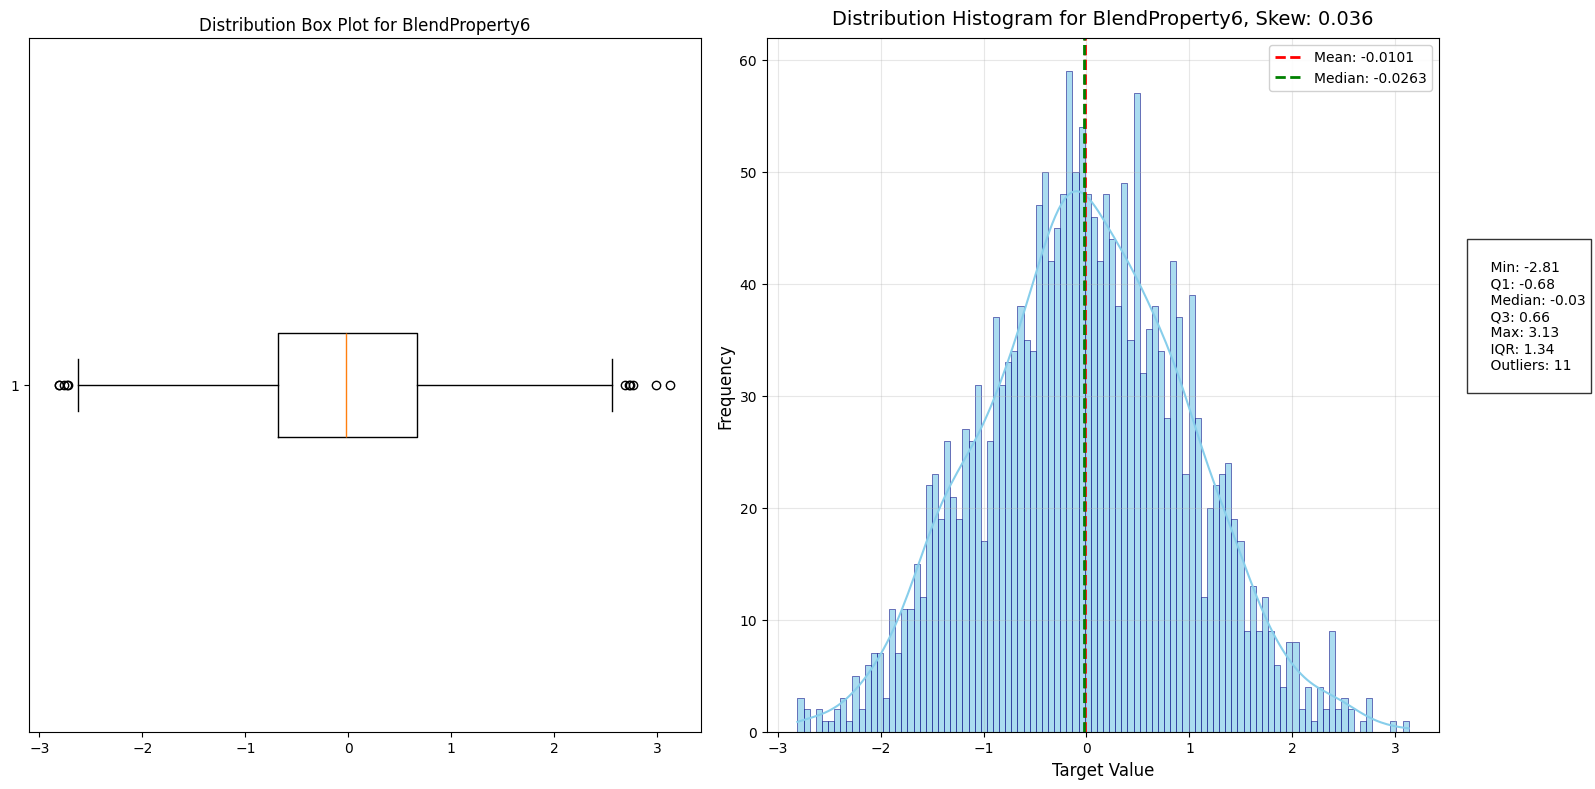

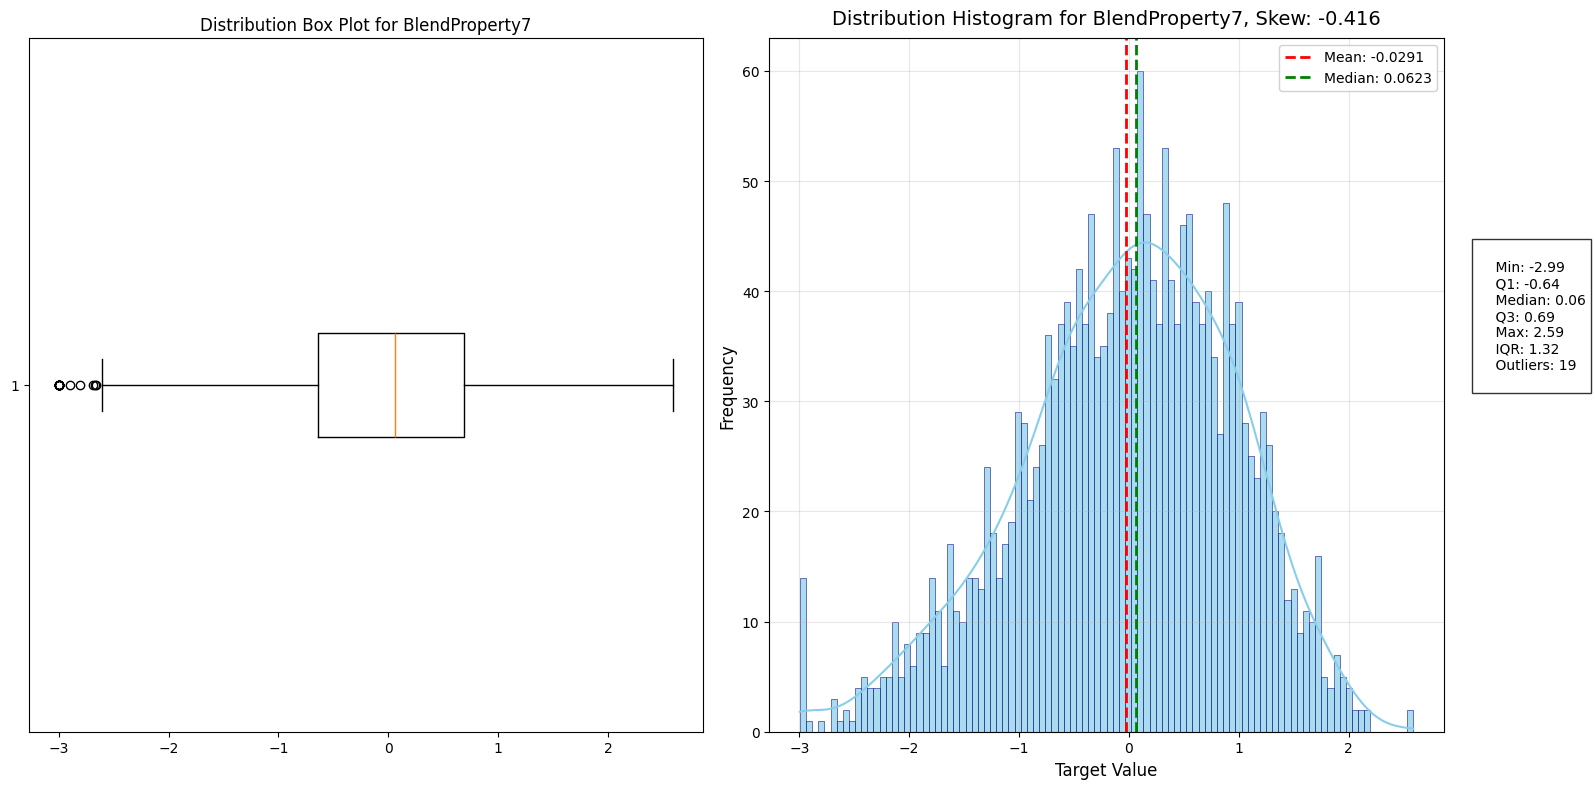

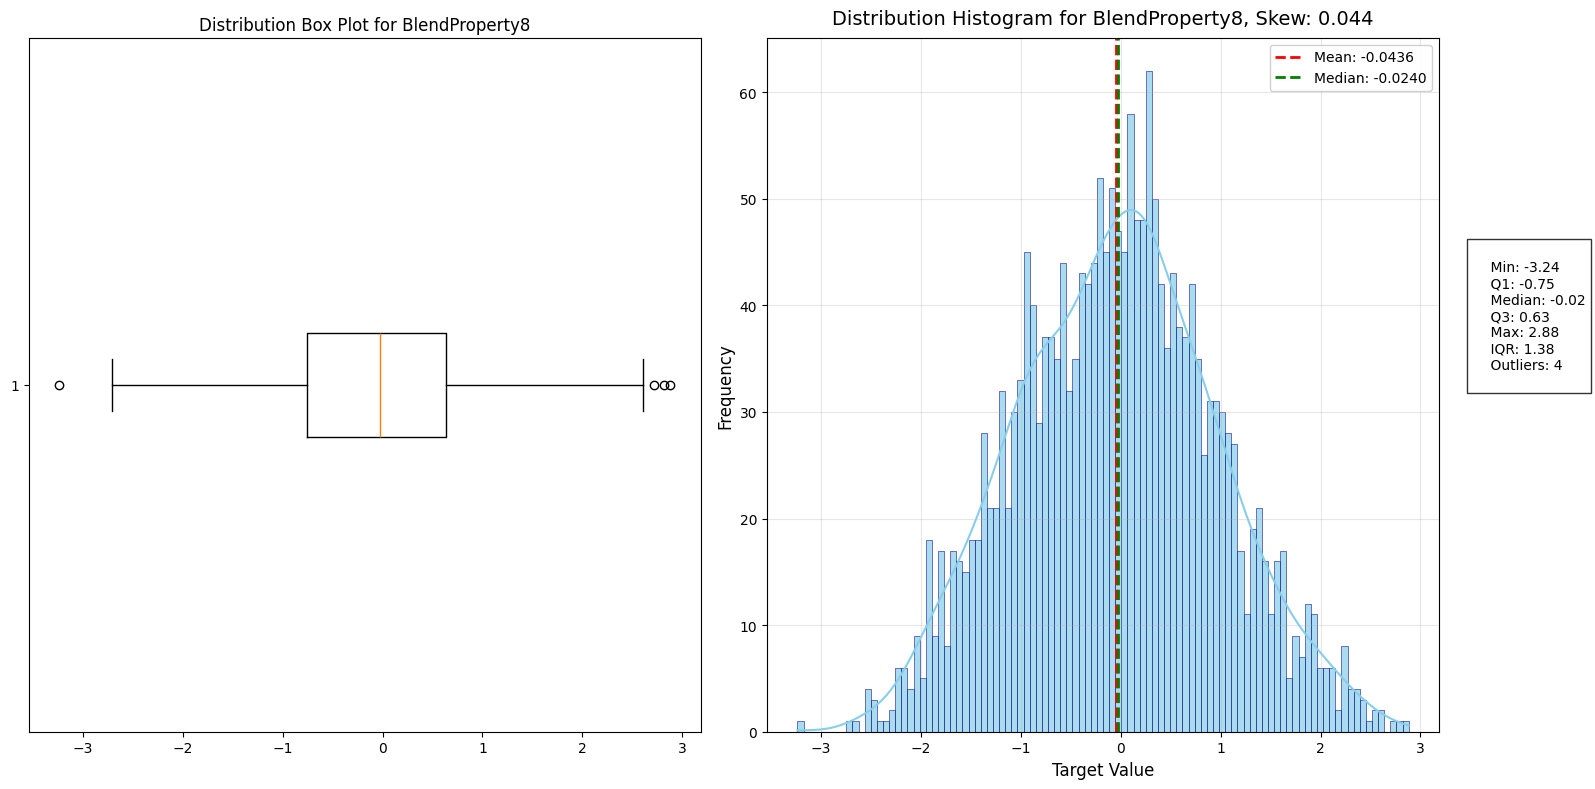

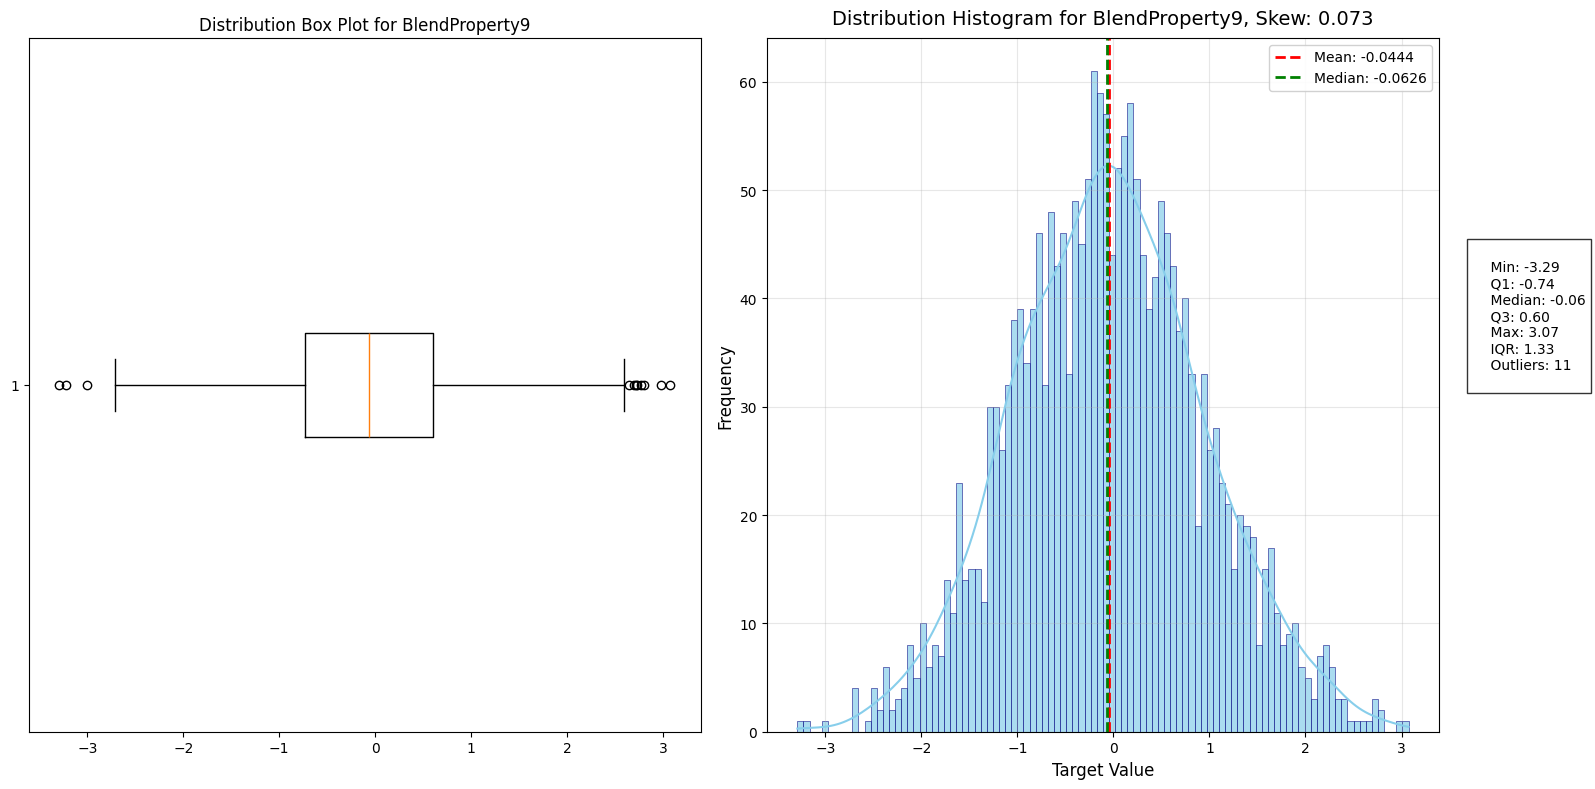

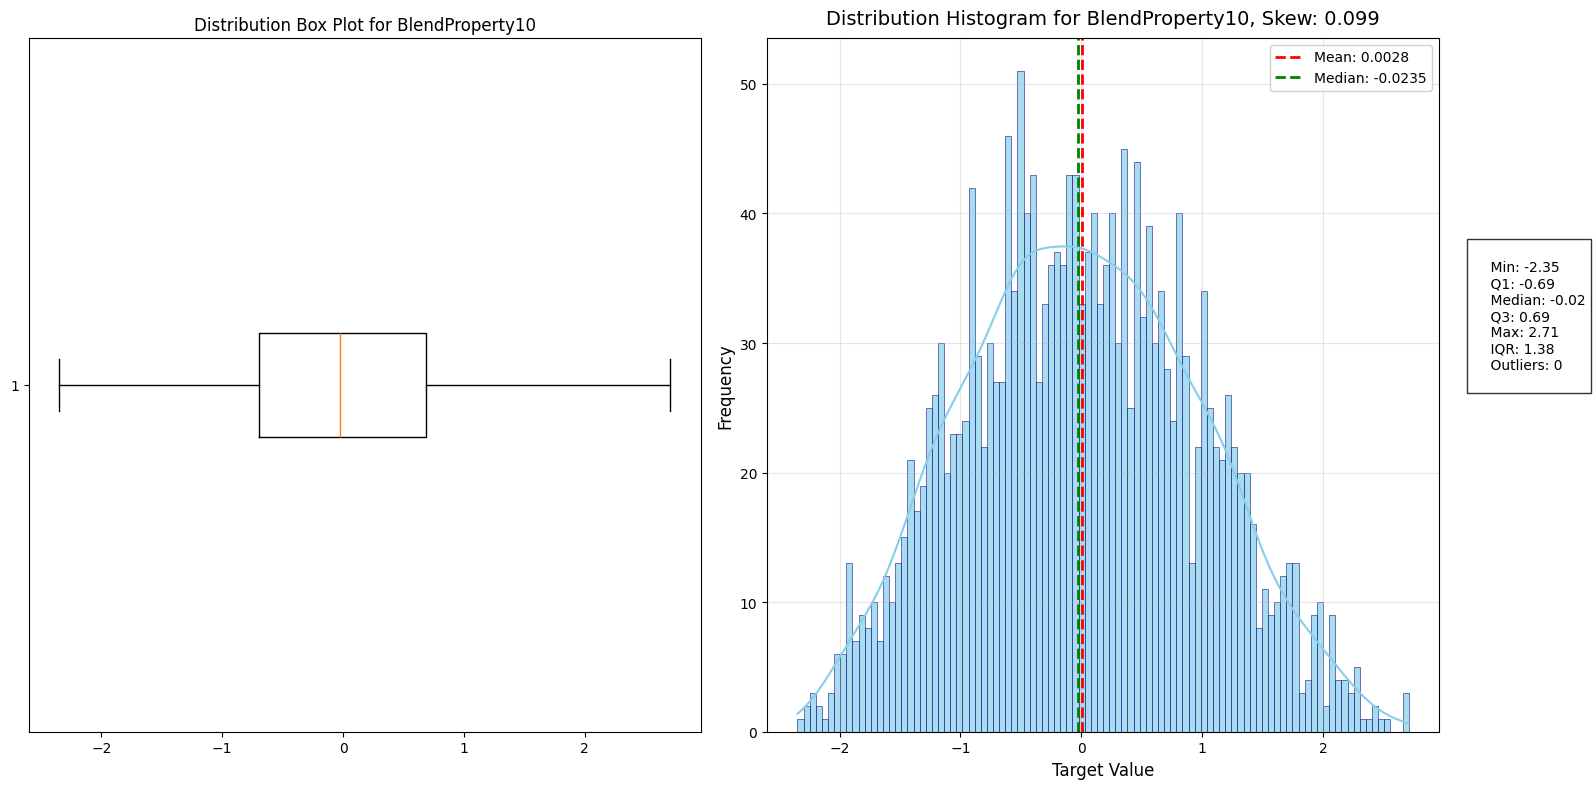

In [39]:
for label in targeColumns:
    outskew(synData, label)

All the above distibutions show that synthetic data almost preserves the distribution as well as the correlation between the columns of the Dataframe, can be used for increase the data points for model training.